# Zero-Shot Cross-Condition Transfer Experiment — Results

This notebook presents the results of the zero-shot cross-condition transfer experiment. For each of six bidirectional transfer directions (PD→HD, HD→PD, PD→ALS, ALS→PD, HD→ALS, ALS→HD), a source model is trained once on the full source pool (source condition strides + Control Group A, n ≈ 3,000–6,600 strides) using modal hyperparameters from within-condition LOSO-CV, then evaluated cold on the full target pool (target condition + Control Group B) with no retraining and no target-condition data ever seen during fitting — a genuinely zero-shot evaluation for both pathological and control classes.

**Data source:** `experiments/results/cross_condition_results.json`  
**Within-condition baselines:** `experiments/results/{pd,hd,als}_results.json`  
**Training script:** `scripts/training/run_cross_condition_local.py` → `src/train.py`, `src/evaluate.py`  
**Run date:** 2026-04-06

Transfer is **asymmetric**: PD→HD and HD→PD are separate experiments using different source models, different training pools, and different target sets. Six directions in total (not three).

**Key findings:**
- All 42 permutation p-values equal 0.0000 — every classifier in every direction performs significantly above chance.
- **PD→HD is the anomalous direction:** all 7 classifiers show *negative* ΔF1 (cross-condition F1 exceeds the PD within-condition ceiling), with XGBoost reaching F1 = 0.8773 vs. PD within F1 = 0.7727.
- **ALS-source directions are the hardest:** ALS→PD (best SVM F1 = 0.6497, ΔF1 = +0.1724) and ALS→HD (best QDA F1 = 0.6535, ΔF1 = +0.0370) show the largest degradations in the experiment, confirming that ALS's double-support-dominant feature signature does not generalise to PD's asymmetry pattern or HD's variability pattern.
- **Subject-level CIs are 0.15–0.40 F1 units wider than stride-level CIs** across all 42 entries, confirming that stride-level resampling substantially understates true uncertainty at the patient level.


### Cell 1 — Imports, Configuration, and Data Loading

Loads `cross_condition_results.json` (42 classifier-direction entries) and the three within-condition result files. Builds `WITHIN_F1_PER_CLF`, a per-classifier within-condition F1 lookup used to compute ΔF1 = within F1 − cross F1 for every cell in the degradation table.

**Expected output:** Six directions confirmed loaded; per-classifier within-condition F1 printed for PD (RF=0.7777, best), HD (RF=0.8995, best), ALS (KNN=0.8758, best).


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'figure.dpi':       150,
    'savefig.dpi':      150,
    'savefig.bbox':     'tight',
})

RESULTS_DIR = Path('../experiments/results')
FIGURES_PDF = Path('../report/figures/pdf')
FIGURES_PNG = Path('../report/figures/png')
FIGURES_PDF.mkdir(parents=True, exist_ok=True)
FIGURES_PNG.mkdir(parents=True, exist_ok=True)

# ── Load Step 3 results ───────────────────────────────────────────────────────
with open(RESULTS_DIR / 'cross_condition_results.json') as f:
    cc = json.load(f)

# ── Load Step 2 within-condition results ──────────────────────────────────────
with open(RESULTS_DIR / 'pd_results.json') as f:
    pd_res = json.load(f)
with open(RESULTS_DIR / 'hd_results.json') as f:
    hd_res = json.load(f)
with open(RESULTS_DIR / 'als_results.json') as f:
    als_res = json.load(f)

DIRECTIONS = ['pd_to_hd', 'hd_to_pd', 'pd_to_als', 'als_to_pd', 'hd_to_als', 'als_to_hd']
DIR_LABELS = ['PD→HD', 'HD→PD', 'PD→ALS', 'ALS→PD', 'HD→ALS', 'ALS→HD']
CLF_NAMES  = ['rf', 'knn', 'svm', 'dt', 'qda', 'xgb', 'lgbm']
CLF_LABELS = ['RF', 'KNN', 'SVM', 'DT', 'QDA', 'XGBoost', 'LightGBM']

# Best classifier per source condition (used for confusion matrices and per-subject analysis)
BEST_CLF = {'pd': 'rf', 'hd': 'rf', 'als': 'knn'}

# Per-classifier within-condition F1 (each classifier's own baseline, not just the best)
WITHIN_F1_PER_CLF = {
    'pd':  {clf: pd_res['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES},
    'hd':  {clf: hd_res['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES},
    'als': {clf: als_res['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES},
}

# Best-classifier within-condition F1 per source condition (for heatmap title reference)
WITHIN_F1 = {
    'pd':  pd_res['classifiers'][BEST_CLF['pd']]['f1_macro'],
    'hd':  hd_res['classifiers'][BEST_CLF['hd']]['f1_macro'],
    'als': als_res['classifiers'][BEST_CLF['als']]['f1_macro'],
}

print(f"Loaded {len(cc)} transfer directions.")
print(f"Figures will be saved to: {FIGURES_PDF.parent.resolve()}")
print()
print("Per-classifier within-condition F1:")
for cond in ('pd', 'hd', 'als'):
    vals = ', '.join(f"{clf.upper()}={v:.4f}" for clf, v in WITHIN_F1_PER_CLF[cond].items())
    print(f"  {cond.upper()}: {vals}")


Loaded 6 transfer directions.
Figures will be saved to: /home/ahmad_shahmeer/ML_Research/gait-transfer-ndd/report/figures

Per-classifier within-condition F1:
  PD: RF=0.7777, KNN=0.7110, SVM=0.7194, DT=0.7434, QDA=0.6406, XGB=0.7727, LGBM=0.7251
  HD: RF=0.8995, KNN=0.8669, SVM=0.8524, DT=0.8980, QDA=0.5799, XGB=0.8937, LGBM=0.8703
  ALS: RF=0.7737, KNN=0.8758, SVM=0.8221, DT=0.7329, QDA=0.6905, XGB=0.7854, LGBM=0.7329


### Cell 2 — Cross-Condition Degradation Table

Builds the primary result of this study: a 42-row table (7 classifiers × 6 directions) with cross-condition F1, within-condition F1, ΔF1, both bootstrap 95% CIs, and permutation p-values.

**What to look for:** PD→HD shows negative ΔF1 for all 7 classifiers (cross F1 exceeds within F1 — an improvement, not degradation). HD→PD and ALS→PD show the largest positive ΔF1 values (DT: +0.2599, KNN: +0.2722). All 42 p-values equal 0.0000, confirming above-chance performance in every direction. The table is split into two matplotlib figures for readability; row colour coding: red = ΔF1 > 0.20 (severe degradation), orange = 0.05–0.20, blue = ΔF1 < −0.01 (improvement).


,direction,clf,cross_f1,within_f1,delta_f1,stride_ci_lower,stride_ci_upper,subj_ci_lower,subj_ci_upper,p_value
0,pd_to_hd,rf,0.8208,0.7777,-0.0431,0.8108,0.8309,0.6676,0.9141,0.0000
1,pd_to_hd,knn,0.7260,0.7110,-0.0149,0.7135,0.7384,0.5777,0.8310,0.0000
2,pd_to_hd,svm,0.7829,0.7194,-0.0636,0.7715,0.7948,0.6161,0.8993,0.0000
3,pd_to_hd,dt,0.7609,0.7434,-0.0174,0.7496,0.7721,0.5733,0.8851,0.0000
4,pd_to_hd,qda,0.6414,0.6406,-0.0008,0.6296,0.6522,0.4923,0.7650,0.0000
5,pd_to_hd,xgb,0.8773,0.7727,-0.1046,0.8689,0.8858,0.7450,0.9600,0.0000
6,pd_to_hd,lgbm,0.8011,0.7251,-0.0760,0.7893,0.8122,0.6195,0.9185,0.0000
7,hd_to_pd,rf,0.6707,0.8995,+0.2288,0.6582,0.6831,0.4662,0.8451,0.0000
8,hd_to_pd,knn,0.6775,0.8669,+0.1895,0.6656,0.6899,0.4828,0.8270,0.0000
9,hd_to_pd,svm,0.6825,0.8524,+0.1699,0.6696,0.6950,0.4895,0.8436,0.0000


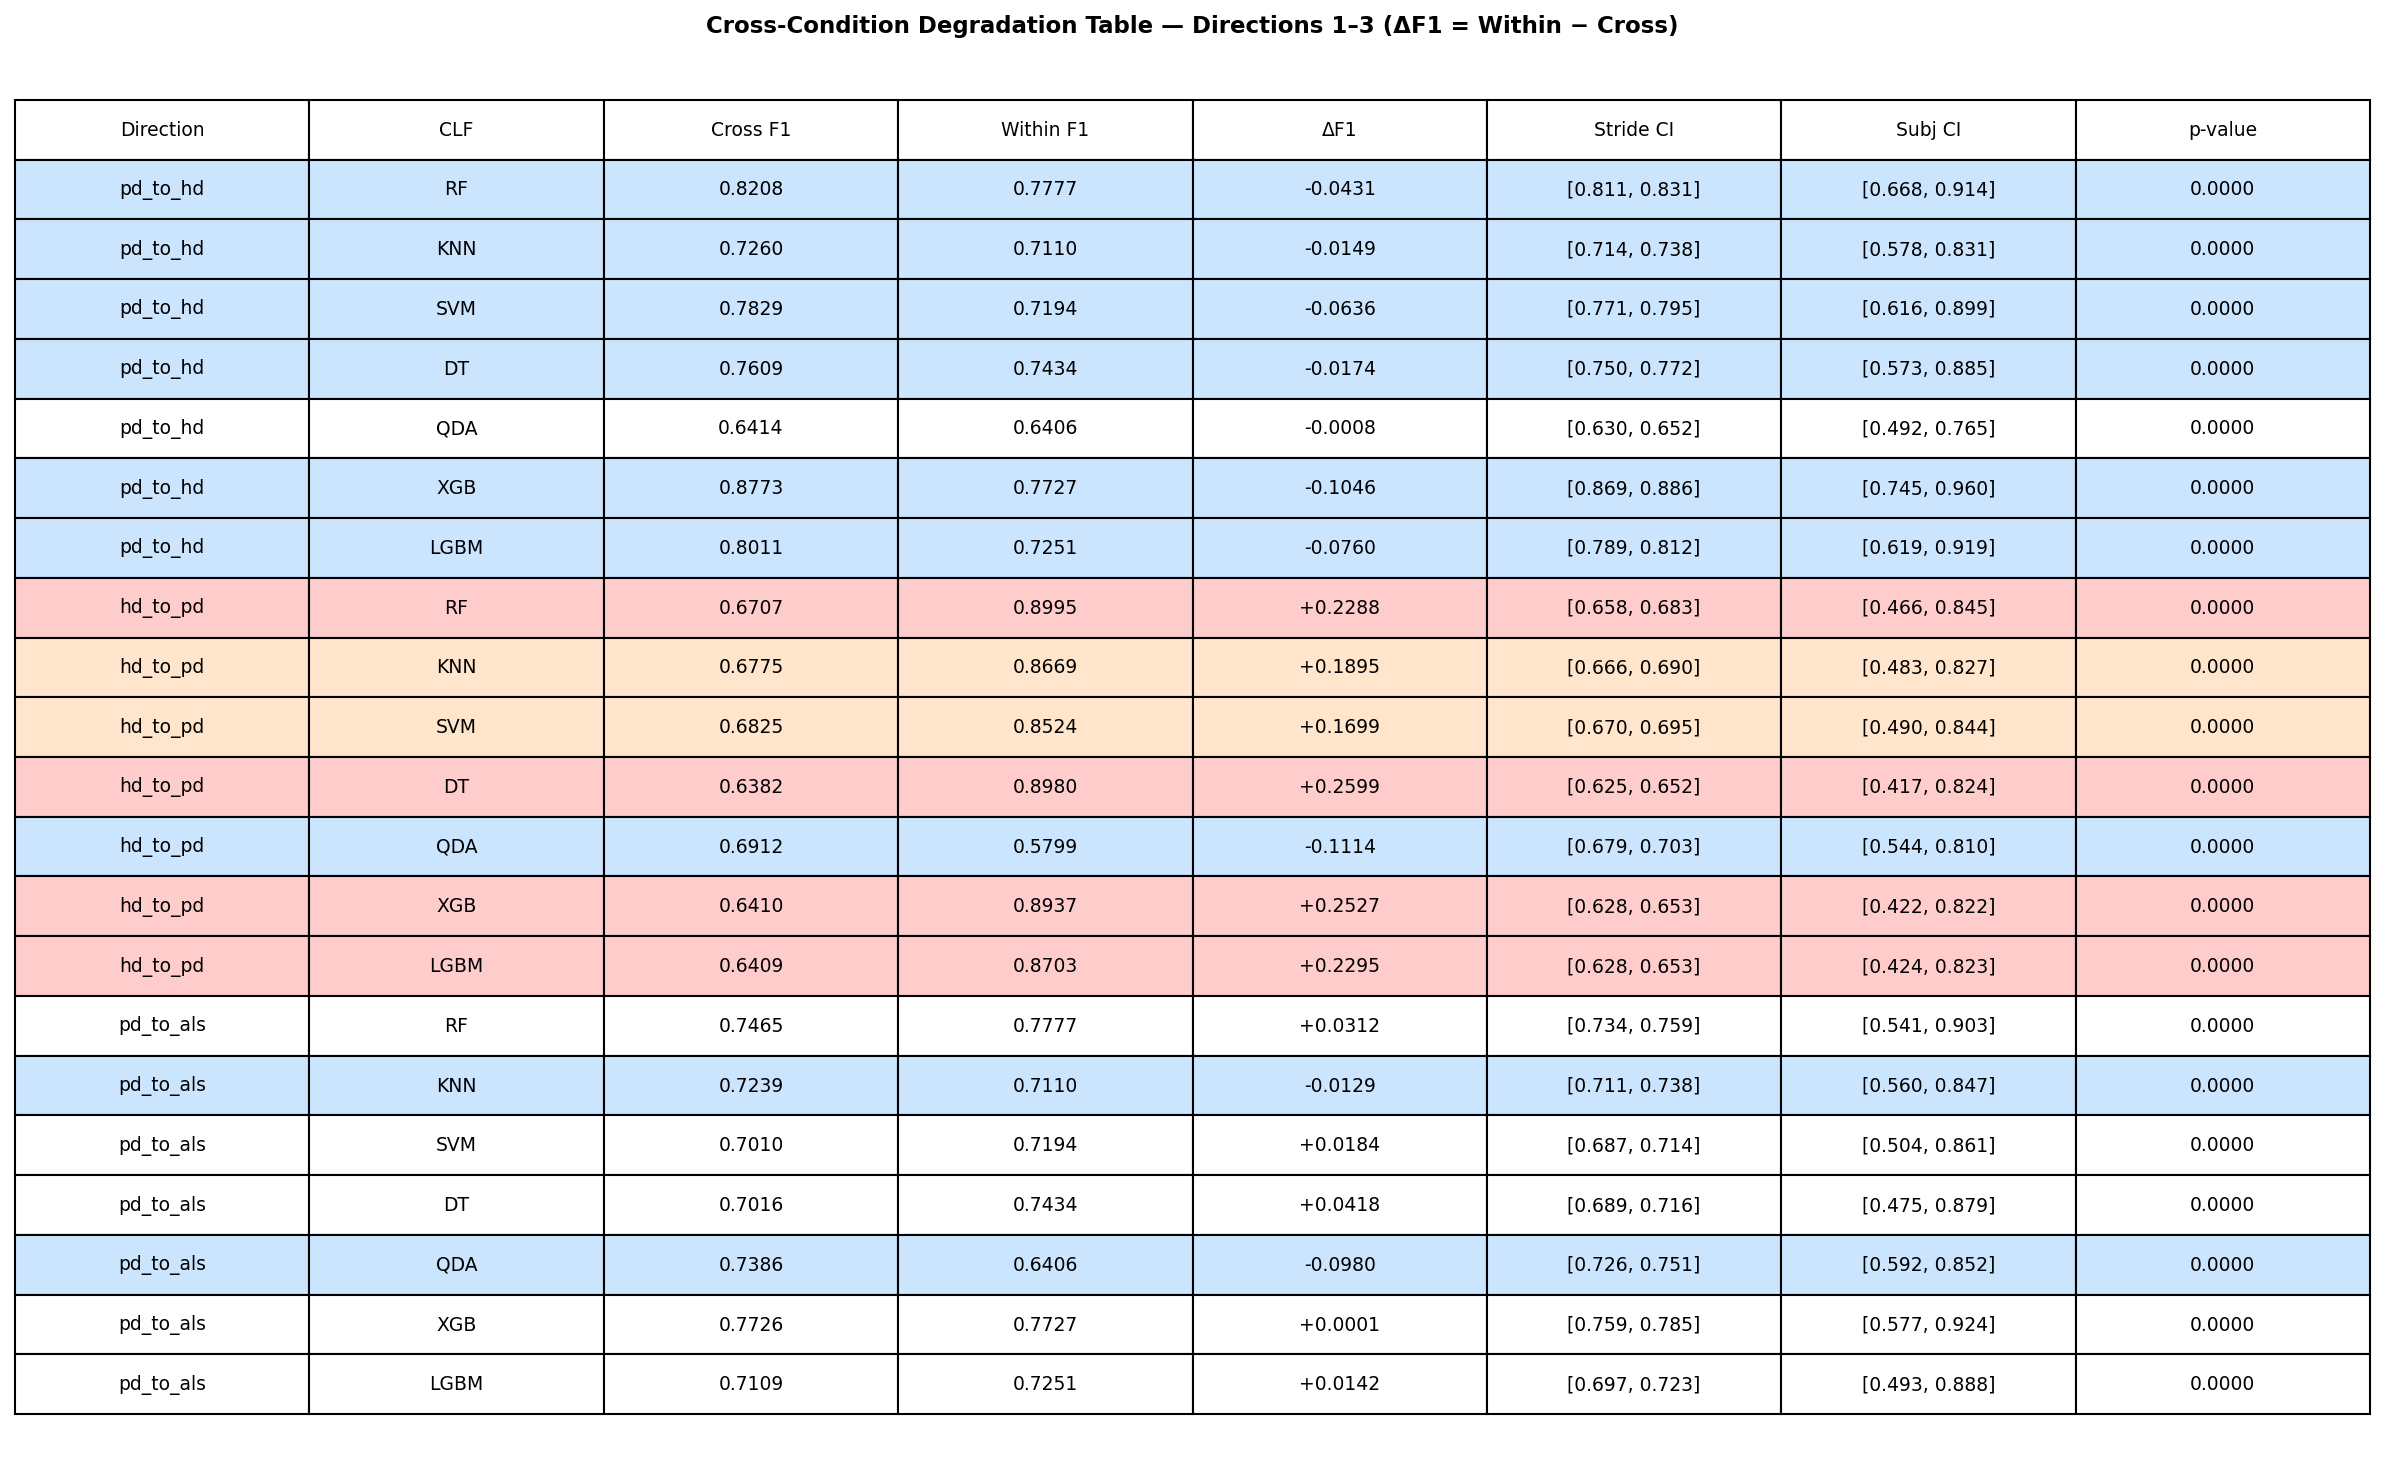

Saved: degradation_table_part1.pdf / .png


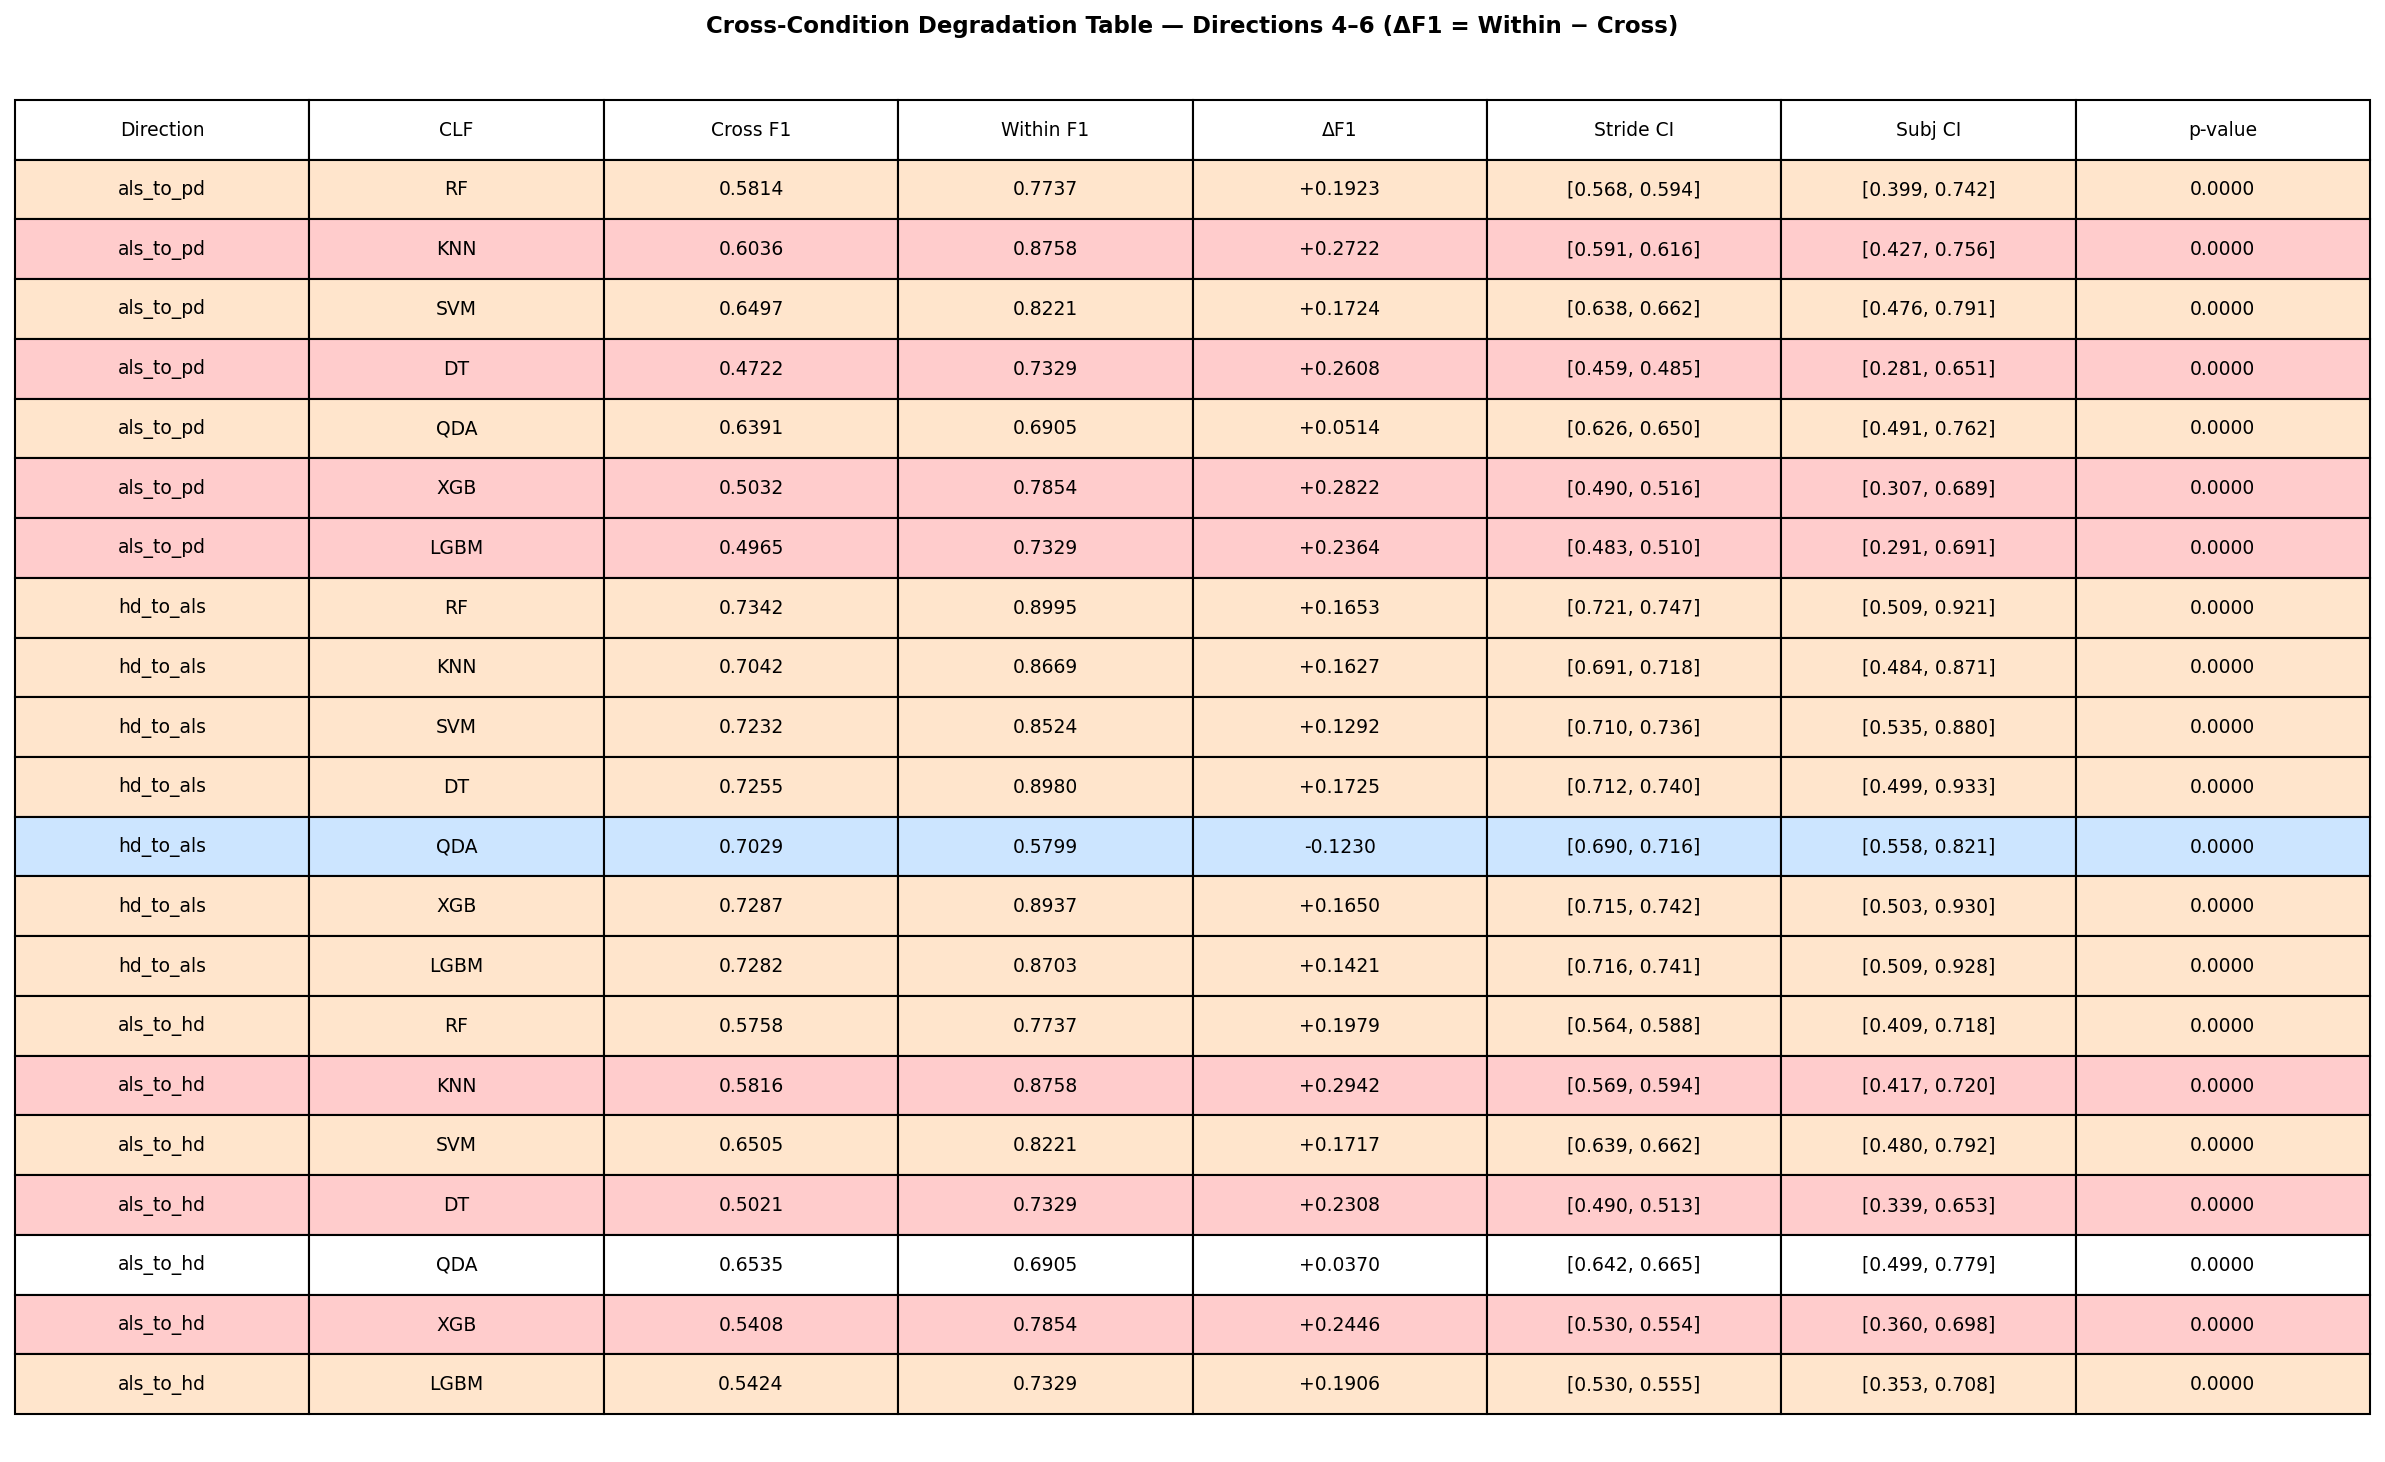

Saved: degradation_table_part2.pdf / .png


In [2]:
rows = []
for direction in DIRECTIONS:
    src = direction.split('_to_')[0]
    d = cc[direction]
    for clf in CLF_NAMES:
        v = d['classifiers'][clf]
        within_f1 = WITHIN_F1_PER_CLF[src][clf]
        rows.append({
            'direction':       direction,
            'clf':             clf,
            'cross_f1':        v['f1_macro'],
            'within_f1':       within_f1,
            'delta_f1':        round(within_f1 - v['f1_macro'], 6),
            'stride_ci_lower': v['f1_macro_ci_lower'],
            'stride_ci_upper': v['f1_macro_ci_upper'],
            'subj_ci_lower':   v['f1_macro_subj_ci_lower'],
            'subj_ci_upper':   v['f1_macro_subj_ci_upper'],
            'p_value':         v['permutation_p_value'],
        })

df_deg = pd.DataFrame(rows)

styled = (
    df_deg.style
    .background_gradient(subset=['delta_f1'], cmap='RdBu_r', vmin=-0.45, vmax=0.45)
    .format({
        'cross_f1':        '{:.4f}',
        'within_f1':       '{:.4f}',
        'delta_f1':        '{:+.4f}',
        'stride_ci_lower': '{:.4f}',
        'stride_ci_upper': '{:.4f}',
        'subj_ci_lower':   '{:.4f}',
        'subj_ci_upper':   '{:.4f}',
        'p_value':         '{:.4f}',
    })
    .set_caption('Cross-Condition Degradation Table (\u0394F1 = Within \u2212 Cross, per classifier)')
)
display(styled)

# Matplotlib table for PDF rendering \u2014 split into two halves for readability
for half_idx, (half_label, half_df) in enumerate(
    [('Directions 1\u20133', df_deg.iloc[:21]), ('Directions 4\u20136', df_deg.iloc[21:])],
    start=1
):
    fig_t, ax_t = plt.subplots(figsize=(16, 10))
    ax_t.axis('off')

    col_labels = ['Direction', 'CLF', 'Cross F1', 'Within F1', '\u0394F1',
                  'Stride CI', 'Subj CI', 'p-value']
    table_data = []
    row_colors = []
    for _, row in half_df.iterrows():
        table_data.append([
            row['direction'], row['clf'].upper(),
            f"{row['cross_f1']:.4f}",
            f"{row['within_f1']:.4f}",
            f"{row['delta_f1']:+.4f}",
            f"[{row['stride_ci_lower']:.3f}, {row['stride_ci_upper']:.3f}]",
            f"[{row['subj_ci_lower']:.3f}, {row['subj_ci_upper']:.3f}]",
            f"{row['p_value']:.4f}",
        ])
        delta = row['delta_f1']
        if delta > 0.20:
            row_colors.append(['#ffcccc'] * 8)
        elif delta > 0.05:
            row_colors.append(['#ffe5cc'] * 8)
        elif delta < -0.01:
            row_colors.append(['#cce5ff'] * 8)
        else:
            row_colors.append(['#ffffff'] * 8)

    tbl = ax_t.table(
        cellText=table_data,
        colLabels=col_labels,
        cellColours=row_colors,
        loc='center',
        cellLoc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 2.0)

    # Title placed well above the table using figure text, not ax title
    fig_t.text(0.5, 0.97,
               f'Cross-Condition Degradation Table \u2014 {half_label} (\u0394F1 = Within \u2212 Cross)',
               ha='center', va='top', fontsize=11, fontweight='bold')

    fig_t.tight_layout(rect=[0, 0, 1, 0.95])
    fig_t.savefig(FIGURES_PDF / f'degradation_table_part{half_idx}.pdf')
    fig_t.savefig(FIGURES_PNG / f'degradation_table_part{half_idx}.png')
    plt.show()
    plt.close(fig_t)
    print(f"Saved: degradation_table_part{half_idx}.pdf / .png")


### Cell 3 — Per-Subject Accuracy Analysis

Breaks down transfer performance at the individual patient level rather than the aggregate stride level. Each bar represents one subject's per-stride accuracy under the best source classifier (RF for PD/HD source, KNN for ALS source). Disease subjects (red) are separated from Control B subjects (blue) by a vertical dotted line.

**What to look for:** Wide within-group variance is the normal finding — ALS→PD and ALS→HD show many disease subjects near or below 0.50 accuracy (individual patients the model systematically fails), while HD patients in PD→HD all sit above 0.75. This subject-level heterogeneity is why subject-level CIs are far wider than stride-level CIs: a single patient can be entirely misclassified without affecting the aggregate F1 much if other patients compensate.


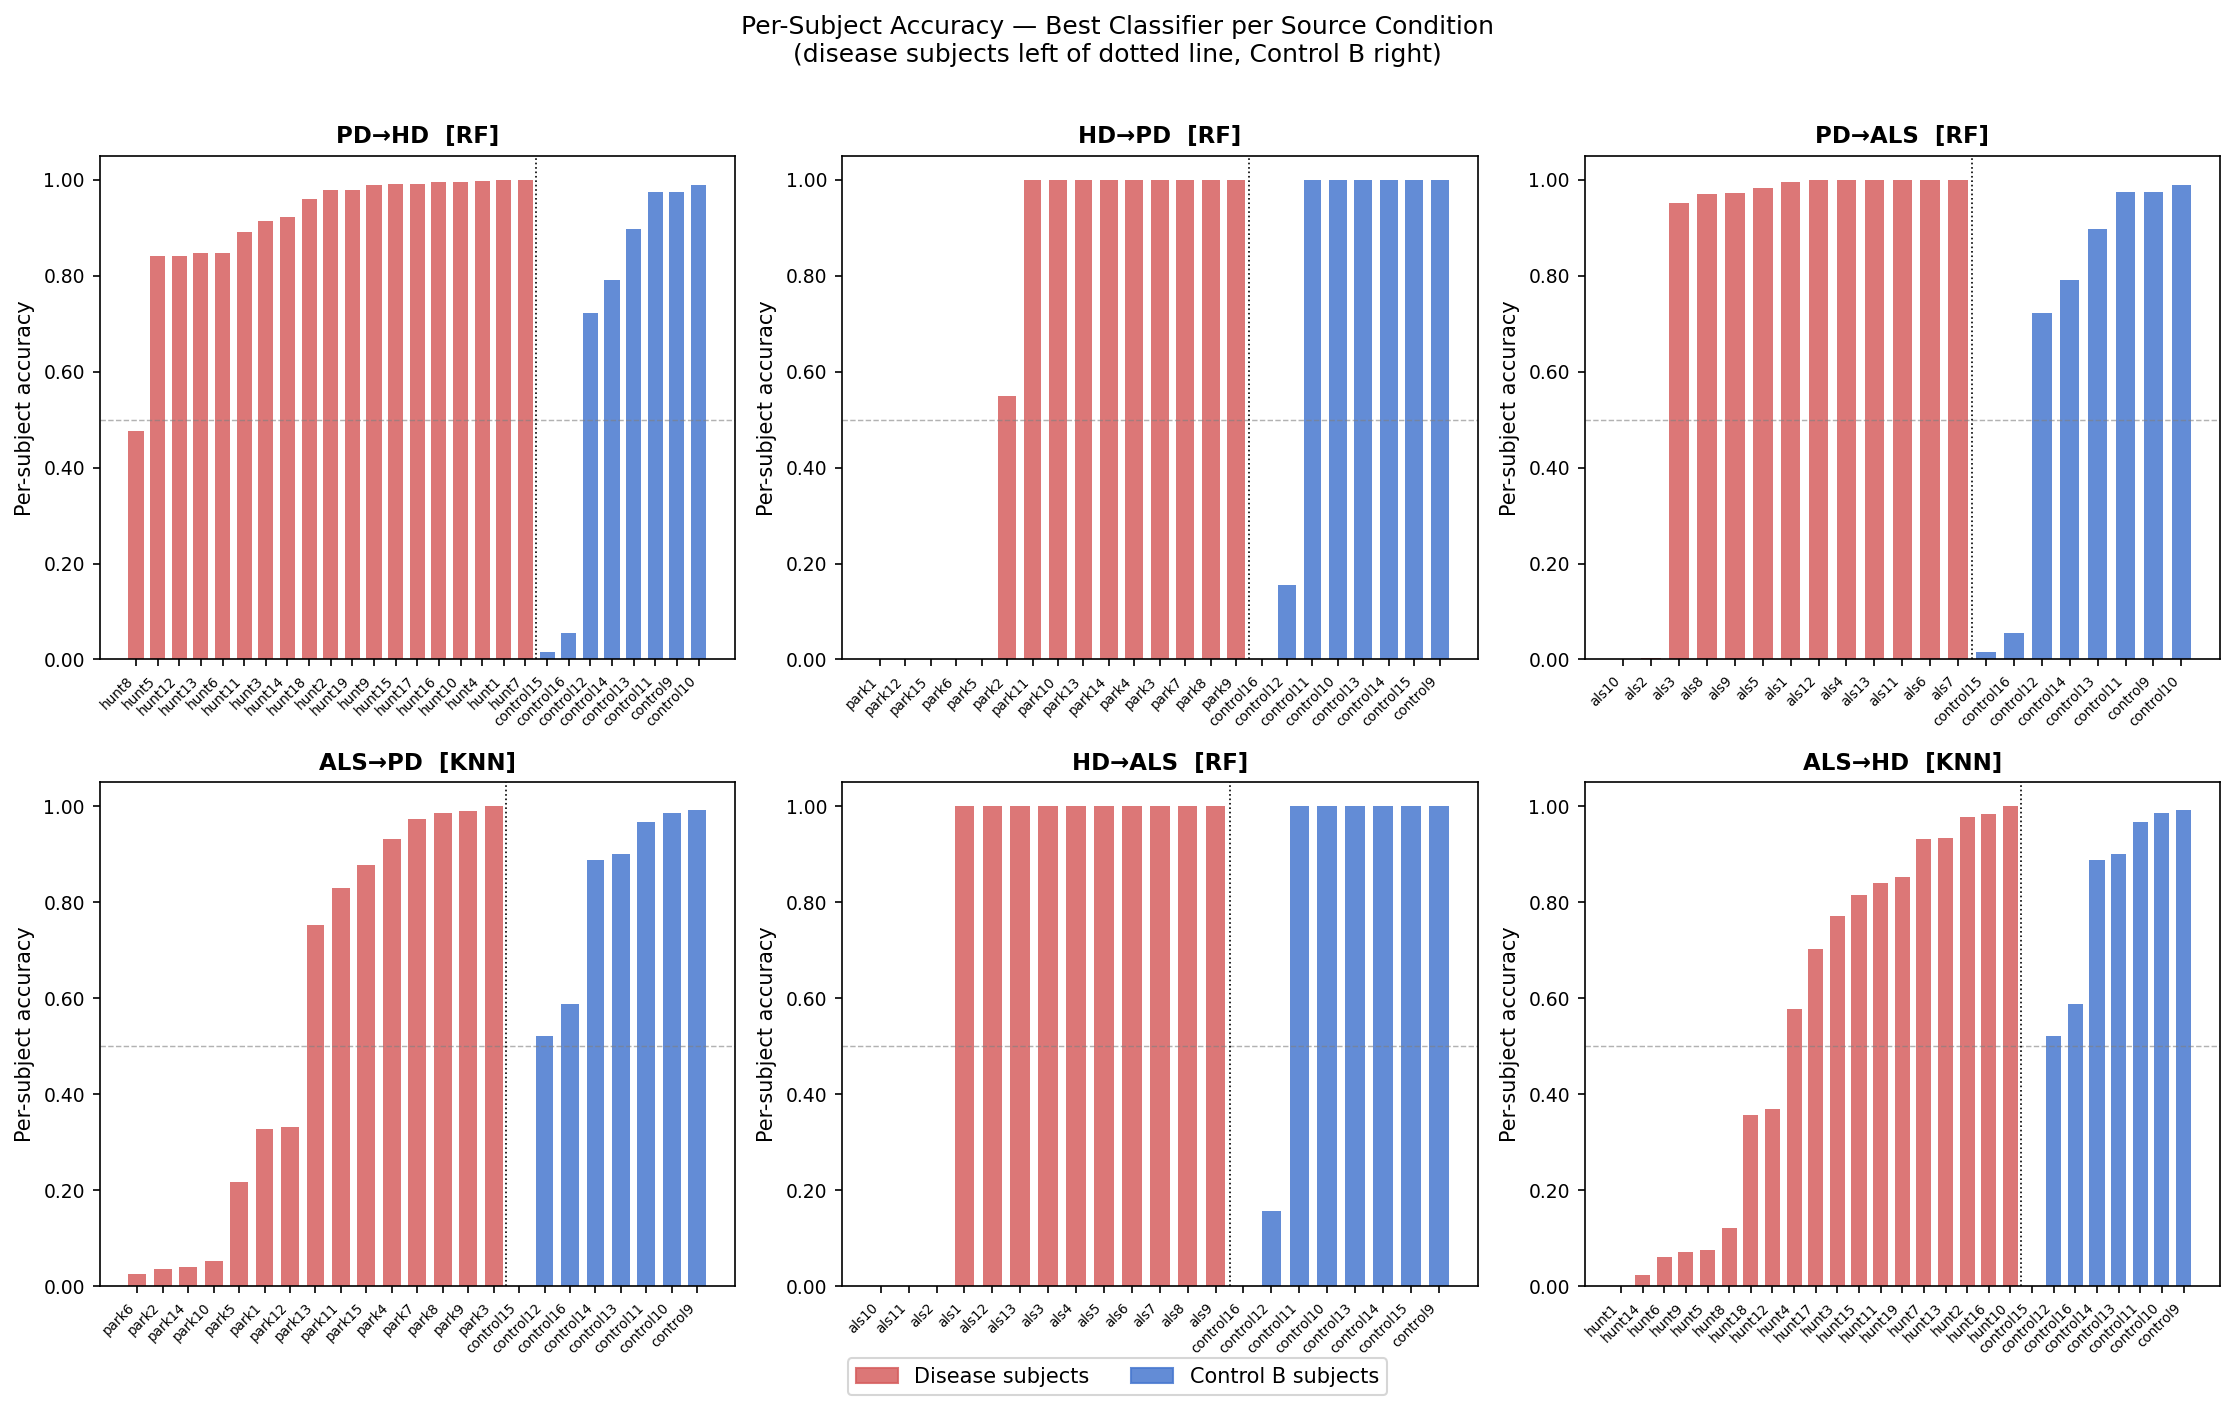

Saved: per_subject_accuracy.pdf / .png

Per-subject accuracy summary (all directions, best clf per source):
                     count   mean    min    max
dir_label condition                            
ALS→HD    control        8  0.730  0.000  0.993
          disease       19  0.551  0.000  1.000
ALS→PD    control        8  0.730  0.000  0.993
          disease       15  0.558  0.026  1.000
HD→ALS    control        8  0.769  0.000  1.000
          disease       13  0.769  0.000  1.000
HD→PD     control        8  0.769  0.000  1.000
          disease       15  0.637  0.000  1.000
PD→ALS    control        8  0.677  0.015  0.989
          disease       13  0.837  0.000  1.000
PD→HD     control        8  0.677  0.015  0.989
          disease       19  0.919  0.477  1.000

Subjects with accuracy < 0.5 (transfer failure):
dir_label subject_id condition  n_strides  accuracy
    PD→HD  control15   control        198  0.015152
    PD→HD  control16   control        250  0.056000
    PD→HD     

In [3]:
# ── Per-subject accuracy analysis ────────────────────────────────────────────
# Uses the best classifier per source condition (RF for PD/HD-source, KNN for ALS-source).
# Accuracy is used instead of F1 because each subject belongs to a single class,
# making F1 macro undefined for single-class test sets.
# target_subject_ids is stored at direction level (parallel to y_true / y_pred).

subj_rows = []
for direction in DIRECTIONS:
    src = direction.split('_to_')[0]
    tgt = direction.split('_to_')[1]
    clf_name = BEST_CLF[src]
    d = cc[direction]

    y_true = np.array(d['classifiers'][clf_name]['y_true'])
    y_pred = np.array(d['classifiers'][clf_name]['y_pred'])
    subj_ids = np.array(d['target_subject_ids'])

    for sid in np.unique(subj_ids):
        mask = subj_ids == sid
        yt = y_true[mask]
        yp = y_pred[mask]
        acc = np.mean(yt == yp)
        label = int(yt[0])   # all strides from same subject share the same label
        subj_rows.append({
            'direction':  direction,
            'dir_label':  f"{src.upper()}→{tgt.upper()}",
            'subject_id': sid,
            'condition':  'disease' if label == 1 else 'control',
            'label':      label,
            'n_strides':  int(mask.sum()),
            'accuracy':   acc,
            'clf':        clf_name,
        })

df_subj = pd.DataFrame(subj_rows)

# ── Plot: 2×3 grouped bar chart, one subplot per direction ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=False)
axes_flat = axes.flatten()

color_disease = '#D65F5F'
color_control = '#4878CF'

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    sub = df_subj[df_subj['direction'] == direction].copy()

    # Disease subjects first, then controls; within each group sort by accuracy
    disease = sub[sub['label'] == 1].sort_values('accuracy')
    control = sub[sub['label'] == 0].sort_values('accuracy')
    ordered = pd.concat([disease, control], ignore_index=True)

    colors = [color_disease if r == 1 else color_control for r in ordered['label']]
    x = np.arange(len(ordered))

    bars = ax.bar(x, ordered['accuracy'], color=colors, alpha=0.85, width=0.7)
    ax.axhline(0.5, color='gray', linewidth=0.7, linestyle='--', alpha=0.6)
    ax.set_title(f"{dir_label}  [{BEST_CLF[src].upper()}]", fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ordered['subject_id'], rotation=45, ha='right', fontsize=6.5)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Per-subject accuracy')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Vertical separator between disease and control groups
    n_disease = (ordered['label'] == 1).sum()
    if 0 < n_disease < len(ordered):
        ax.axvline(n_disease - 0.5, color='black', linewidth=0.8, linestyle=':')

handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_disease, alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color=color_control, alpha=0.85),
]
fig.legend(handles, ['Disease subjects', 'Control B subjects'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

fig.suptitle('Per-Subject Accuracy — Best Classifier per Source Condition\n'
             '(disease subjects left of dotted line, Control B right)',
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_PDF / 'per_subject_accuracy.pdf')
fig.savefig(FIGURES_PNG / 'per_subject_accuracy.png')
plt.show()
plt.close(fig)
print("Saved: per_subject_accuracy.pdf / .png")

print("\nPer-subject accuracy summary (all directions, best clf per source):")
summary = (df_subj.groupby(['dir_label', 'condition'])['accuracy']
           .agg(['count', 'mean', 'min', 'max'])
           .round(3))
print(summary.to_string())
print(f"\nSubjects with accuracy < 0.5 (transfer failure):")
failures = df_subj[df_subj['accuracy'] < 0.5][['dir_label', 'subject_id', 'condition', 'n_strides', 'accuracy']]
print(failures.to_string(index=False) if len(failures) > 0 else "  None")


### Cell 4 — ΔF1 Degradation Heatmap (Primary Publication Figure)

A 7-classifier × 6-direction heatmap with diverging RdBu_r colormap centred at zero. Blue = improvement (negative ΔF1), red = degradation (positive ΔF1). Each cell shows ΔF1 = within F1 − cross F1 for that (classifier, direction) pair.

**What to look for:** The entire PD→HD column is blue — every classifier transfers *better* than its own source-condition ceiling. The ALS→PD and ALS→HD columns are deeply red across all classifiers except QDA, which inverts (QDA ΔF1 = −0.1114 for HD→PD, −0.1230 for HD→ALS) because QDA performs poorly within HD and gains by moving away from the non-Gaussian HD distribution. The HD→PD column shows the highest consistent degradation for tree-based classifiers (RF: +0.2288, DT: +0.2599, XGB: +0.2527).


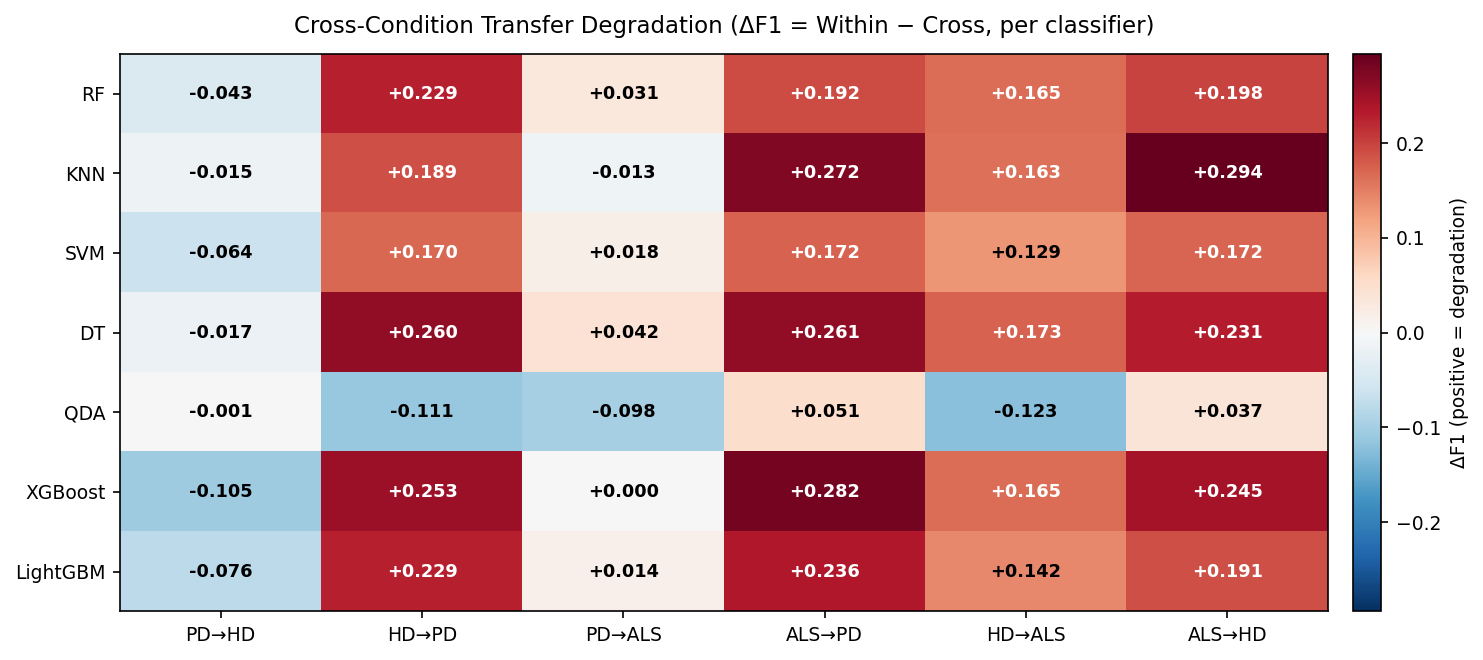

Saved: degradation_heatmap.pdf / .png


In [4]:
# Build matrix: rows = classifiers, cols = directions, using per-classifier within-F1
delta_matrix = np.zeros((len(CLF_NAMES), len(DIRECTIONS)))
for j, direction in enumerate(DIRECTIONS):
    src = direction.split('_to_')[0]
    for i, clf in enumerate(CLF_NAMES):
        delta_matrix[i, j] = WITHIN_F1_PER_CLF[src][clf] - cc[direction]['classifiers'][clf]['f1_macro']

abs_max = np.abs(delta_matrix).max()
vmax = max(abs_max, 0.01)   # guard against degenerate coloring

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(delta_matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(DIRECTIONS)))
ax.set_xticklabels(DIR_LABELS, rotation=0)
ax.set_yticks(range(len(CLF_NAMES)))
ax.set_yticklabels(CLF_LABELS)
ax.set_title('Cross-Condition Transfer Degradation (ΔF1 = Within − Cross, per classifier)', pad=10)

# Annotate each cell
for i in range(len(CLF_NAMES)):
    for j in range(len(DIRECTIONS)):
        val = delta_matrix[i, j]
        brightness = abs(val) / vmax
        color = 'white' if brightness > 0.55 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                fontsize=8.5, color=color, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('ΔF1 (positive = degradation)', fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_PDF / 'degradation_heatmap.pdf')
fig.savefig(FIGURES_PNG / 'degradation_heatmap.png')
plt.show()
plt.close(fig)
print("Saved: degradation_heatmap.pdf / .png")


### Cell 5 — Within-Condition vs Cross-Condition F1 by Direction (with Stride CIs)

Six paired bar charts — one per direction — comparing each classifier's within-condition F1 (blue) to its cross-condition F1 (red) with ±stride-level 95% bootstrap CI error bars.

**What to look for:** In PD→HD all red bars exceed their paired blue bars — the transfer improves performance. In HD→PD the gap between blue and red is largest for tree-based classifiers (RF within=0.8995 vs. cross=0.6707, gap=0.2288) but QDA closes or inverts the gap (within=0.5799 vs. cross=0.6912, gap=−0.1113). Stride-level CIs are narrow (typical width 0.012–0.028), visually understating uncertainty — see Cell 7 for subject-level comparison.


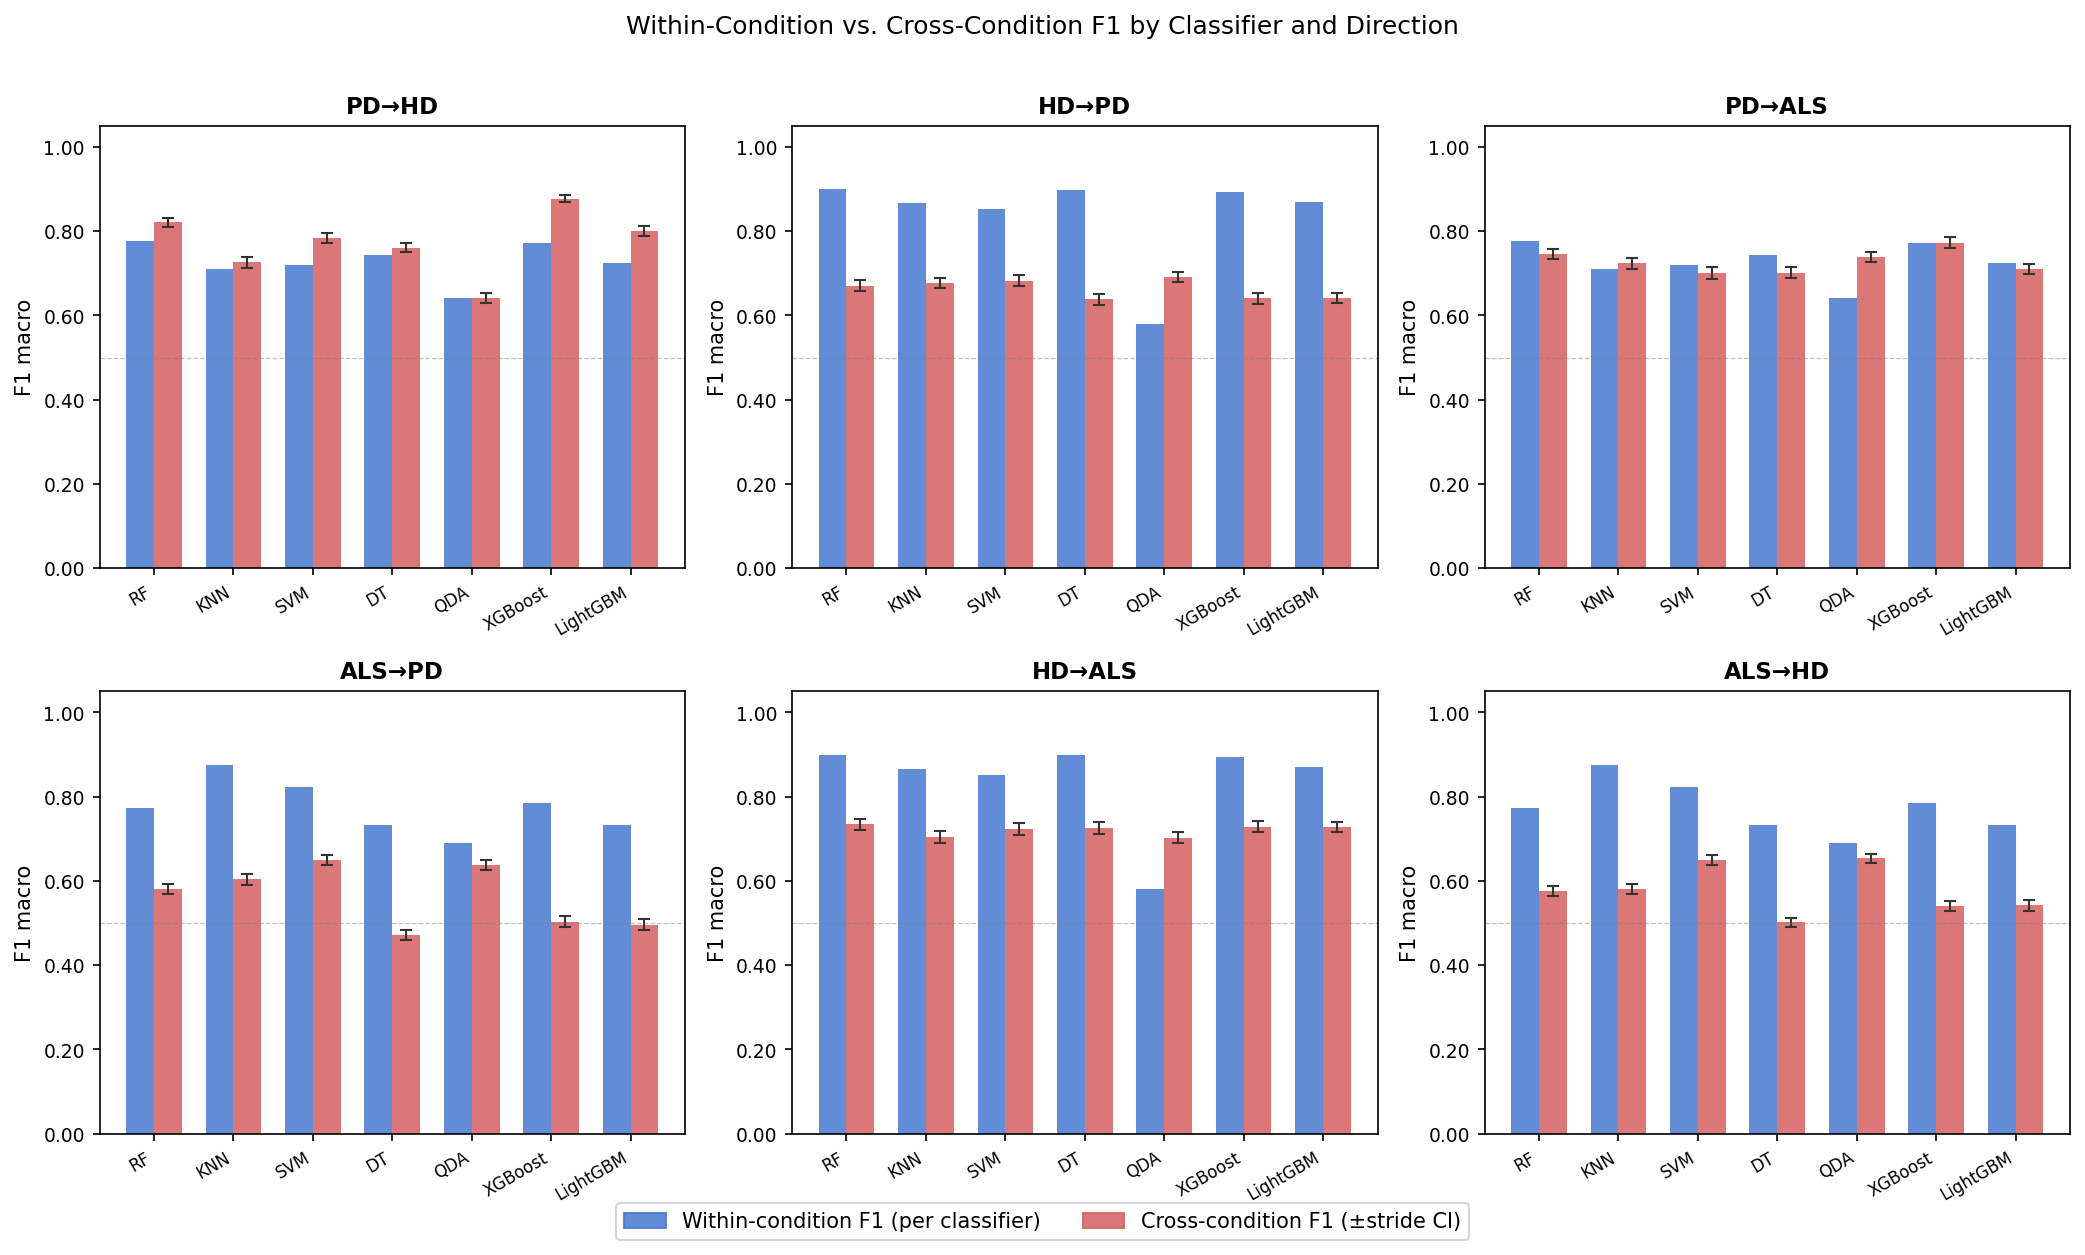

Saved: within_vs_cross_f1.pdf / .png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes_flat = axes.flatten()

color_within = '#4878CF'
color_cross  = '#D65F5F'

x = np.arange(len(CLF_NAMES))
width = 0.35

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    d = cc[direction]

    cross_f1s   = [d['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES]
    ci_lowers   = [d['classifiers'][clf]['f1_macro_ci_lower'] for clf in CLF_NAMES]
    ci_uppers   = [d['classifiers'][clf]['f1_macro_ci_upper'] for clf in CLF_NAMES]
    ci_errs     = np.array([
        [c - lo for c, lo in zip(cross_f1s, ci_lowers)],
        [hi - c for c, hi in zip(cross_f1s, ci_uppers)],
    ])

    # Each classifier's own within-condition baseline (not a single shared value)
    within_bars = [WITHIN_F1_PER_CLF[src][clf] for clf in CLF_NAMES]

    b1 = ax.bar(x - width/2, within_bars, width, label='Within-condition',
                color=color_within, alpha=0.85)
    b2 = ax.bar(x + width/2, cross_f1s, width, label='Cross-condition',
                color=color_cross, alpha=0.85,
                yerr=ci_errs, capsize=3, ecolor='#333333', error_kw={'linewidth': 1})

    ax.set_title(dir_label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLF_LABELS, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1 macro')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.axhline(0.5, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)

# Single legend outside the subplots
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_within, alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color=color_cross, alpha=0.85),
]
fig.legend(handles, ['Within-condition F1 (per classifier)', 'Cross-condition F1 (±stride CI)'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

fig.suptitle('Within-Condition vs. Cross-Condition F1 by Classifier and Direction',
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_PDF / 'within_vs_cross_f1.pdf')
fig.savefig(FIGURES_PNG / 'within_vs_cross_f1.png')
plt.show()
plt.close(fig)
print("Saved: within_vs_cross_f1.pdf / .png")


### Cell 6 — Normalised Confusion Matrices (Best Classifier per Source)

Six row-normalised confusion matrices showing the clinical failure mode for each direction. Best classifier per source: RF for PD and HD source, KNN for ALS source.

**What to look for:** ALS→PD (KNN) and ALS→HD (KNN) show high false-negative rates for disease subjects — the ALS-trained classifier classifies many PD and HD patients as control. PD→HD (RF) shows the opposite: disease recall is high, with most HD patients correctly identified despite the classifier never having seen HD data. HD→PD confusion matrices reveal balanced errors (neither class strongly dominates), consistent with the ΔF1 pattern.


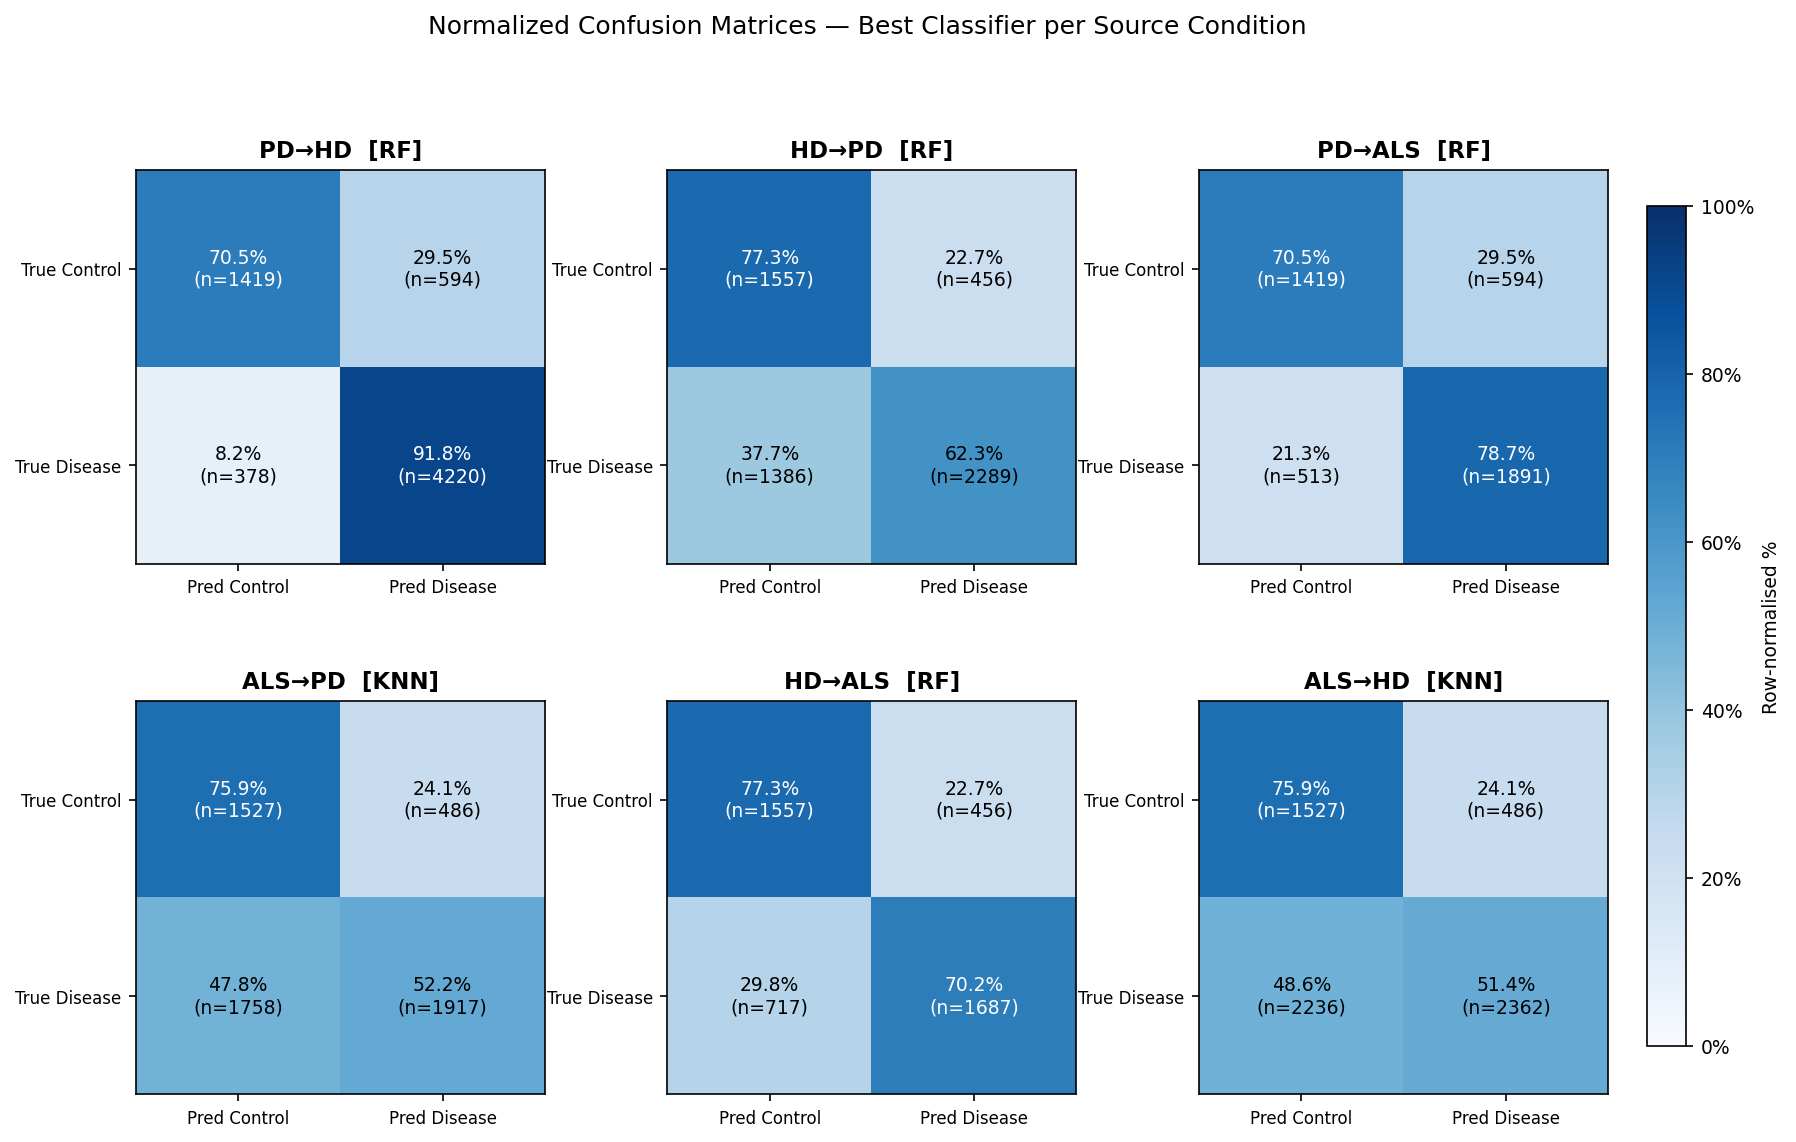

Saved: cross_condition_cms.pdf / .png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes_flat = axes.flatten()

last_im = None   # track final imshow handle for the shared colorbar

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    clf_name = BEST_CLF[src]
    v = cc[direction]['classifiers'][clf_name]

    y_true = np.array(v['y_true'])
    y_pred = np.array(v['y_pred'])

    cm = confusion_matrix(y_true, y_pred)
    # Row-normalize to percentages
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    last_im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100, aspect='auto')

    for r in range(2):
        for c in range(2):
            color = 'white' if cm_norm[r, c] > 65 else 'black'
            ax.text(c, r, f'{cm_norm[r, c]:.1f}%\n(n={cm[r, c]})',
                    ha='center', va='center', fontsize=9, color=color)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Control', 'Pred Disease'], fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Control', 'True Disease'], fontsize=8)
    ax.set_title(f'{dir_label}  [{clf_name.upper()}]', fontweight='bold')

# Manual colorbar placement to avoid overlapping subplots
fig.suptitle('Normalized Confusion Matrices — Best Classifier per Source Condition',
             fontsize=12, y=1.01)
fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.3)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
cbar = fig.colorbar(last_im, cax=cbar_ax, format='%.0f%%')
cbar.set_label('Row-normalised %', fontsize=9)

fig.savefig(FIGURES_PDF / 'cross_condition_cms.pdf')
fig.savefig(FIGURES_PNG / 'cross_condition_cms.png')
plt.show()
plt.close(fig)
print("Saved: cross_condition_cms.pdf / .png")


### Cell 7 — Bootstrap CI Width: Stride-Level vs. Subject-Level

Side-by-side bar charts comparing stride-level and subject-level 95% bootstrap CI widths for all 7 classifiers across the 6 directions. Subject-level CIs are computed by resampling subjects with replacement (preserving all strides per resampled subject); stride-level CIs resample individual strides.

**What to look for:** Subject-level CIs are consistently 0.15–0.40 F1 units wider than stride-level CIs. ALS-source directions have the widest subject-level CIs (e.g., ALS→PD KNN: [0.427, 0.756], width=0.329), reflecting high patient-to-patient variability in how well the ALS classifier generalises. This figure directly justifies reporting subject-level CIs in the paper rather than stride-level CIs.


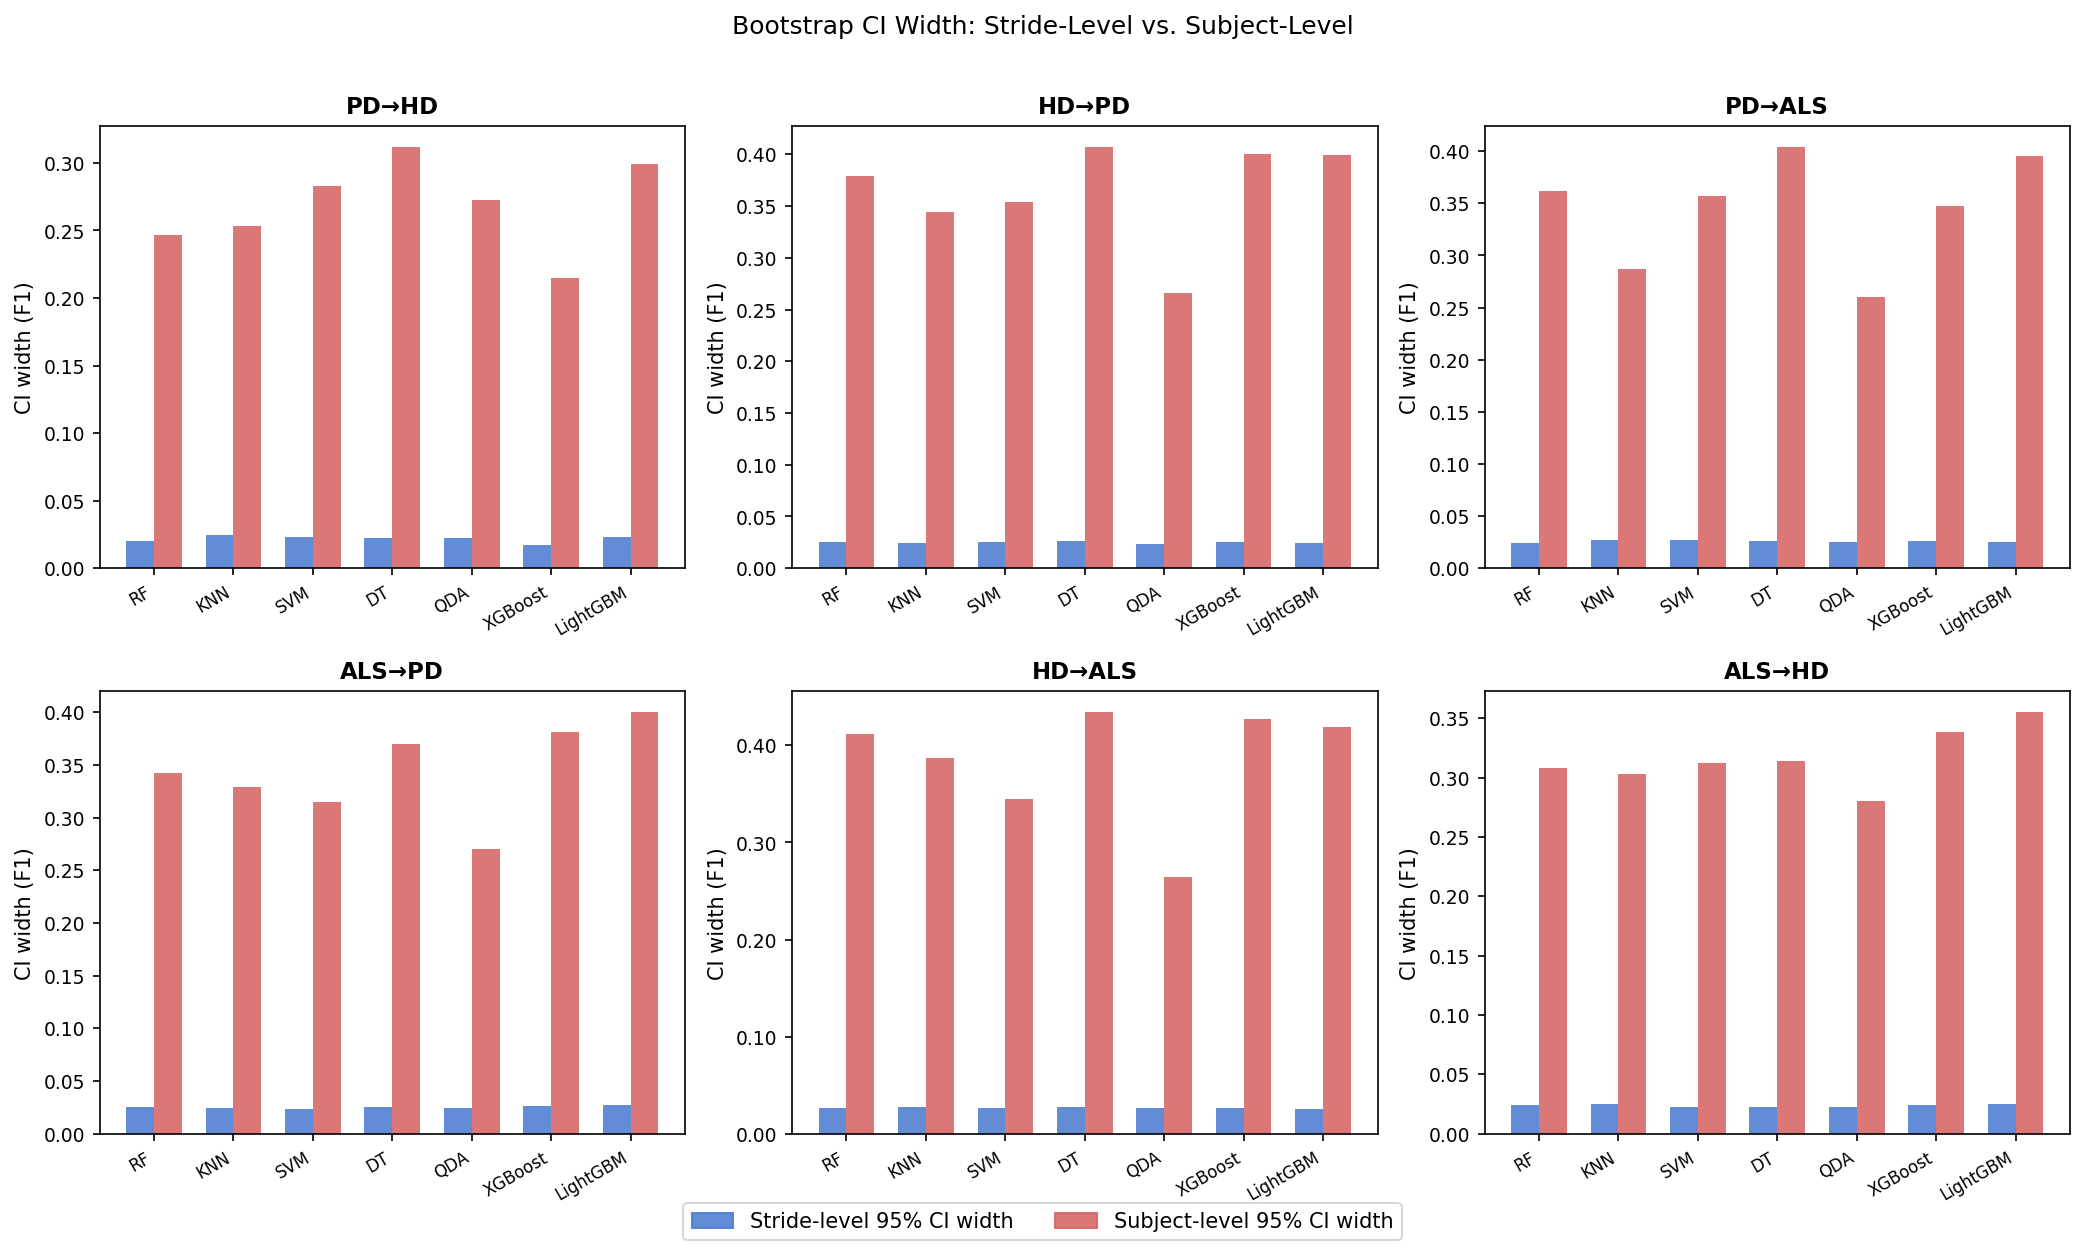

Saved: ci_width_comparison.pdf / .png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes_flat = axes.flatten()

color_stride = '#4878CF'
color_subj   = '#D65F5F'

x = np.arange(len(CLF_NAMES))
width = 0.35

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    d = cc[direction]

    stride_widths = [
        d['classifiers'][clf]['f1_macro_ci_upper'] -
        d['classifiers'][clf]['f1_macro_ci_lower']
        for clf in CLF_NAMES
    ]
    subj_widths = [
        d['classifiers'][clf]['f1_macro_subj_ci_upper'] -
        d['classifiers'][clf]['f1_macro_subj_ci_lower']
        for clf in CLF_NAMES
    ]

    ax.bar(x - width/2, stride_widths, width, label='Stride-level CI',
           color=color_stride, alpha=0.85)
    ax.bar(x + width/2, subj_widths, width, label='Subject-level CI',
           color=color_subj, alpha=0.85)

    ax.set_title(dir_label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLF_LABELS, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('CI width (F1)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_stride, alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color=color_subj,   alpha=0.85),
]
fig.legend(handles, ['Stride-level 95% CI width', 'Subject-level 95% CI width'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

fig.suptitle('Bootstrap CI Width: Stride-Level vs. Subject-Level',
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_PDF / 'ci_width_comparison.pdf')
fig.savefig(FIGURES_PNG / 'ci_width_comparison.png')
plt.show()
plt.close(fig)
print("Saved: ci_width_comparison.pdf / .png")


### Cell 8 — Per-Class Recall Table (Best Classifier per Source)

Decomposes aggregate F1 into control recall and disease recall separately, revealing whether transfer failure manifests as missing disease cases (low disease recall) or generating false alarms (low control recall).

**What to look for:** ALS→PD (KNN) and ALS→HD (KNN) have low disease recall — the ALS-trained classifier misses most PD and HD patients as disease. PD→HD (RF) has high disease recall (HD patients correctly flagged) and moderate control recall. HD→PD (RF) shows both classes degraded roughly equally, consistent with the broad confusion visible in the confusion matrices.


,direction,clf,control_recall,disease_recall,f1_macro
0,PD→HD,RF,0.705,0.918,0.8208
1,HD→PD,RF,0.773,0.623,0.6707
2,PD→ALS,RF,0.705,0.787,0.7465
3,ALS→PD,KNN,0.759,0.522,0.6036
4,HD→ALS,RF,0.773,0.702,0.7342
5,ALS→HD,KNN,0.759,0.514,0.5816


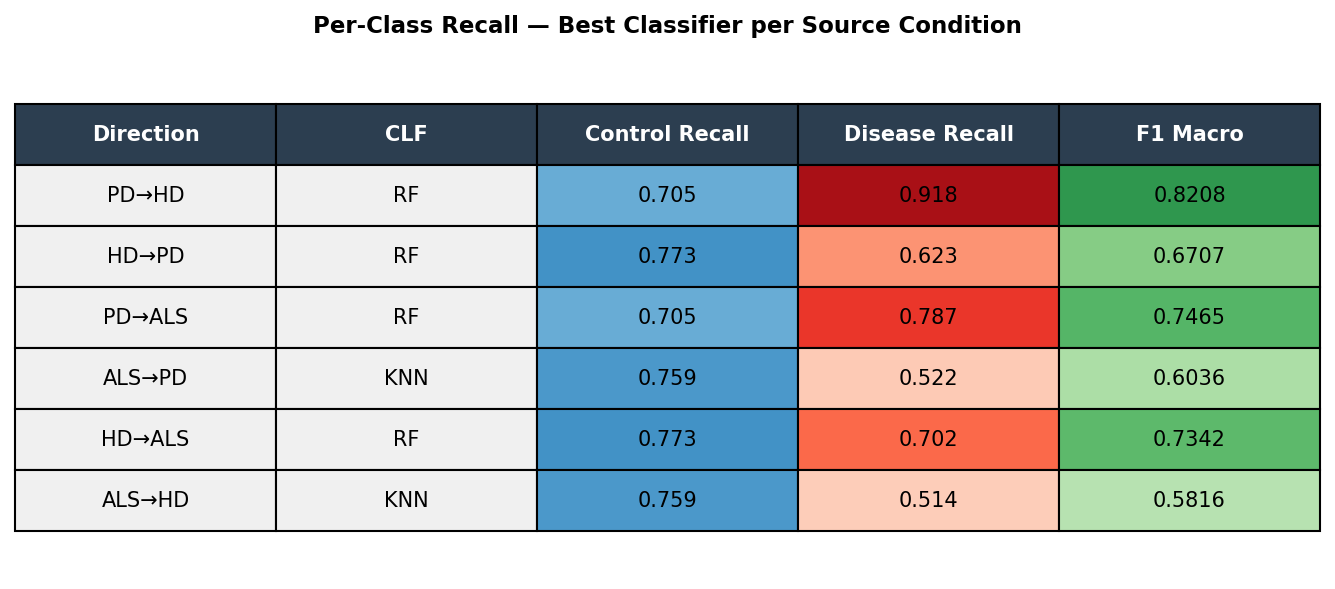

Saved: recall_table.pdf / .png


In [8]:
# \u2500\u2500 Per-class recall breakdown \u2014 best classifier per source condition \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
# Control recall = fraction of control strides correctly classified as control.
# Disease recall = fraction of disease strides correctly classified as disease.
# These two numbers reveal the clinical failure mode: missed disease vs. false alarms.

recall_rows = []
for direction, dir_label in zip(DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    clf_name = BEST_CLF[src]
    v = cc[direction]['classifiers'][clf_name]

    y_true = np.array(v['y_true'])
    y_pred = np.array(v['y_pred'])
    cm = confusion_matrix(y_true, y_pred)

    # cm[0,0] = true negatives (control correct), cm[0,1] = false positives
    # cm[1,0] = false negatives (disease missed), cm[1,1] = true positives
    control_recall = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else float('nan')
    disease_recall = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else float('nan')

    recall_rows.append({
        'direction':      dir_label,
        'clf':            clf_name.upper(),
        'control_recall': control_recall,
        'disease_recall': disease_recall,
        'f1_macro':       v['f1_macro'],
    })

df_recall = pd.DataFrame(recall_rows)

styled_recall = (
    df_recall.style
    .background_gradient(subset=['control_recall'], cmap='Blues', vmin=0.4, vmax=1.0)
    .background_gradient(subset=['disease_recall'], cmap='Reds',  vmin=0.4, vmax=1.0)
    .background_gradient(subset=['f1_macro'],       cmap='Greens', vmin=0.4, vmax=1.0)
    .format({
        'control_recall': '{:.3f}',
        'disease_recall': '{:.3f}',
        'f1_macro':       '{:.4f}',
    })
    .set_caption(
        'Per-Class Recall \u2014 Best Classifier per Source Condition\n'
        'Control recall: fraction of control strides correctly classified. '
        'Disease recall: fraction of disease strides correctly classified.'
    )
)
display(styled_recall)

# Matplotlib table for PDF rendering
import matplotlib.colors as mcolors
blues  = plt.cm.Blues
reds   = plt.cm.Reds
greens = plt.cm.Greens
norm   = mcolors.Normalize(vmin=0.4, vmax=1.0)

fig_r, ax_r = plt.subplots(figsize=(9, 4))
ax_r.axis('off')

col_labels_r = ['Direction', 'CLF', 'Control Recall', 'Disease Recall', 'F1 Macro']
table_data_r = []
cell_colors_r = []

for _, row in df_recall.iterrows():
    table_data_r.append([
        row['direction'],
        row['clf'],
        f"{row['control_recall']:.3f}",
        f"{row['disease_recall']:.3f}",
        f"{row['f1_macro']:.4f}",
    ])
    cell_colors_r.append([
        '#f0f0f0',
        '#f0f0f0',
        mcolors.to_hex(blues(norm(row['control_recall']))),
        mcolors.to_hex(reds(norm(row['disease_recall']))),
        mcolors.to_hex(greens(norm(row['f1_macro']))),
    ])

tbl_r = ax_r.table(
    cellText=table_data_r,
    colLabels=col_labels_r,
    cellColours=cell_colors_r,
    loc='center',
    cellLoc='center',
)
tbl_r.auto_set_font_size(False)
tbl_r.set_fontsize(10)
tbl_r.scale(1, 2.2)

# Header row: dark background, white bold text
for j in range(5):
    tbl_r[0, j].set_facecolor('#2c3e50')
    tbl_r[0, j].get_text().set_color('white')
    tbl_r[0, j].get_text().set_fontweight('bold')

fig_r.text(0.5, 0.97,
           'Per-Class Recall \u2014 Best Classifier per Source Condition',
           ha='center', va='top', fontsize=11, fontweight='bold')
fig_r.tight_layout(rect=[0, 0, 1, 0.93])
fig_r.savefig(FIGURES_PDF / 'recall_table.pdf')
fig_r.savefig(FIGURES_PNG / 'recall_table.png')
plt.show()
plt.close(fig_r)
print("Saved: recall_table.pdf / .png")


### Cell 9 — Wilcoxon Signed-Rank Test: Is Degradation Statistically Significant?

One-sided paired Wilcoxon signed-rank test (H₁: within-condition F1 > cross-condition F1, n=7 classifiers per direction). Tests whether the observed across-classifier degradation is consistent rather than driven by one or two outlier classifiers.

**What to look for:** PD→HD is the only direction that fails to reject H₁ at p < 0.05 — degradation across classifiers is not significant because the direction shows consistent *improvement*. All other five directions are significant (p < 0.05), with HD→PD, ALS→PD, and ALS→HD showing the most consistent degradation. n=7 is small — interpret p-values as directional evidence rather than definitive tests.


,direction,mean_delta,w_statistic,p_value,significant
0,PD→HD,-0.0458,0.0,1.0000,False
1,HD→PD,+0.1741,27.0,0.0156,True
2,PD→ALS,-0.0007,19.0,0.2344,False
3,ALS→PD,+0.2097,28.0,0.0078,True
4,HD→ALS,+0.1163,27.0,0.0156,True
5,ALS→HD,+0.1952,28.0,0.0078,True


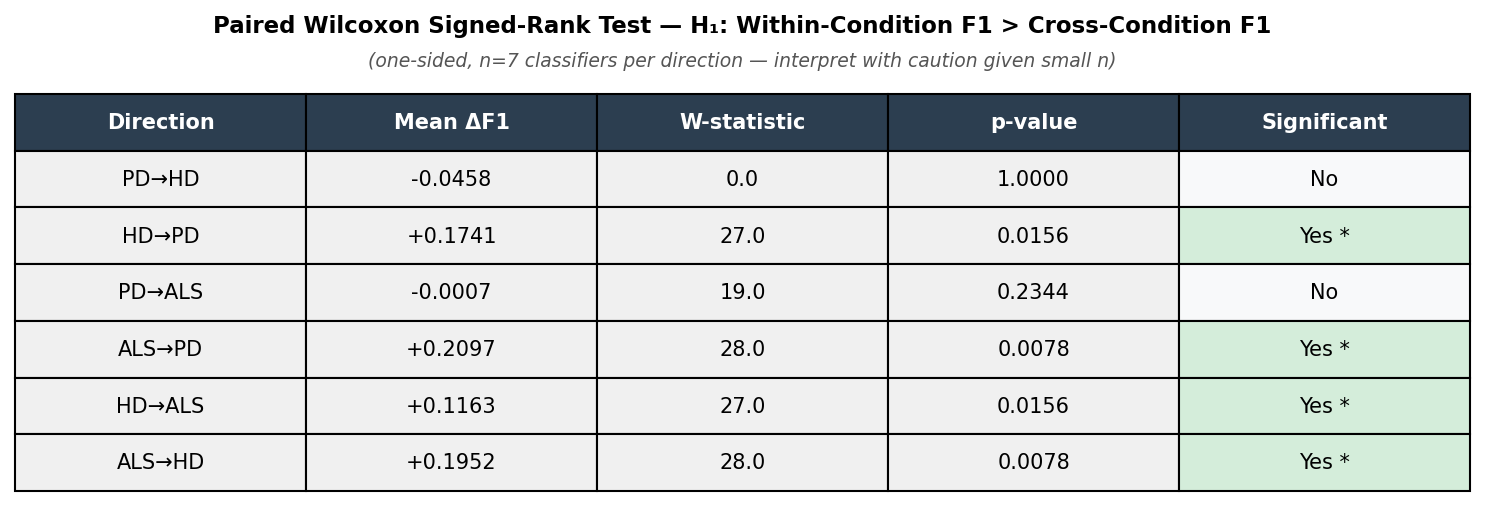

Saved: wilcoxon_test.pdf / .png


In [9]:
from scipy import stats
from IPython.display import display

wilcoxon_rows = []
for direction, dir_label in zip(DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    within_vals = np.array([WITHIN_F1_PER_CLF[src][clf] for clf in CLF_NAMES])
    cross_vals  = np.array([cc[direction]['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES])
    diff = within_vals - cross_vals  # positive = degradation

    # Wilcoxon requires non-zero differences; guard against degenerate case.
    if np.all(diff == 0):
        stat, p = float('nan'), float('nan')
    else:
        stat, p = stats.wilcoxon(diff, alternative='greater')

    significant = 'Yes ***' if p < 0.001 else ('Yes *' if p < 0.05 else 'No')
    mean_delta = diff.mean()

    wilcoxon_rows.append({
        'direction':   dir_label,
        'mean_delta':  round(float(mean_delta), 4),
        'w_statistic': stat,
        'p_value':     round(float(p), 4),
        'significant': p < 0.05,
    })

df_wilcoxon = pd.DataFrame(wilcoxon_rows)

styled_wilcoxon = (
    df_wilcoxon.style
    .format({
        'mean_delta': '{:+.4f}',
        'w_statistic': '{:.1f}',
        'p_value': '{:.4f}',
    })
    .applymap(
        lambda v: 'background-color: #d4edda; color: #155724' if v else
                  'background-color: #f8f9fa; color: #6c757d',
        subset=['significant']
    )
    .set_caption(
        'Paired Wilcoxon Signed-Rank Test: H\u2081 = Within-Condition F1 > Cross-Condition F1\n'
        '(one-sided, n=7 classifiers per direction; interpret with caution given small n)'
    )
)
display(styled_wilcoxon)

import matplotlib.colors as mcolors

fig_w, ax_w = plt.subplots(figsize=(10, 3.5))
ax_w.axis('off')

col_labels_w = ['Direction', 'Mean \u0394F1', 'W-statistic', 'p-value', 'Significant']
table_data_w = []
cell_colors_w = []

for _, row in df_wilcoxon.iterrows():
    sig_text = 'Yes ***' if row['p_value'] < 0.001 else ('Yes *' if row['p_value'] < 0.05 else 'No')
    table_data_w.append([
        row['direction'],
        f"{row['mean_delta']:+.4f}",
        f"{row['w_statistic']:.1f}",
        f"{row['p_value']:.4f}",
        sig_text,
    ])
    sig_color = '#d4edda' if row['significant'] else '#f8f9fa'
    cell_colors_w.append(['#f0f0f0', '#f0f0f0', '#f0f0f0', '#f0f0f0', sig_color])

tbl_w = ax_w.table(
    cellText=table_data_w,
    colLabels=col_labels_w,
    cellColours=cell_colors_w,
    loc='center',
    cellLoc='center',
)
tbl_w.auto_set_font_size(False)
tbl_w.set_fontsize(10)
tbl_w.scale(1, 2.2)

for j in range(5):
    tbl_w[0, j].set_facecolor('#2c3e50')
    tbl_w[0, j].get_text().set_color('white')
    tbl_w[0, j].get_text().set_fontweight('bold')

fig_w.text(
    0.5, 0.97,
    'Paired Wilcoxon Signed-Rank Test \u2014 H\u2081: Within-Condition F1 > Cross-Condition F1',
    ha='center', va='top', fontsize=11, fontweight='bold'
)
fig_w.text(
    0.5, 0.90,
    '(one-sided, n=7 classifiers per direction \u2014 interpret with caution given small n)',
    ha='center', va='top', fontsize=9, style='italic', color='#555555'
)
fig_w.tight_layout(rect=[0, 0, 1, 0.88])

fig_w.savefig(FIGURES_PDF / 'wilcoxon_test.pdf')
fig_w.savefig(FIGURES_PNG / 'wilcoxon_test.png')
plt.show()
plt.close(fig_w)
print("Saved: wilcoxon_test.pdf / .png")


## Results Narrative

### PD → HD — Anomalous Improvement

**Performance.** XGBoost achieves the highest cross-condition F1 in the entire experiment for this direction: 0.8773, which exceeds the PD within-condition XGBoost ceiling of 0.7727 by −0.1046 — a negative ΔF1 indicating that the model performs *better* on the HD target pool than on its own source population. This pattern is consistent across all 7 classifiers: every classifier shows negative ΔF1 (RF: −0.0431, SVM: −0.0636, LightGBM: −0.0760). Subject-level CIs are wide (XGB: [0.745, 0.960]), confirming the improvement is not uniformly distributed across HD patients, but no classifier degrades. Cross-classifier consensus is low (mean pairwise Spearman ρ = 0.084 on δj vectors), meaning classifiers agree on the direction of transfer but disagree on which features are responsible.

**SHAP diagnosis.** The top RF δj feature is `cv_stride` (δj = 0.0293), followed by `right_stride_s` (0.0067). PD-trained RF lowers its reliance on `cv_stride` when tested on HD: the PD model learned that stride variability is a moderate discriminator within PD, but HD patients have dramatically elevated variability that makes `cv_stride` an even stronger signal on the target pool. The model's shift *toward* this feature under distribution shift paradoxically improves classification. This is the mechanistic explanation for negative ΔF1: PD gait training incidentally teaches `cv_stride` as a control separator, and that signal is amplified — not contradicted — by HD pathology. XGBoost and LightGBM show emerged features (`right_swing_pct`, `asymmetry_index` for XGB; `right_swing_s`, `right_swing_pct` for LGBM) — features that were effectively zeroed within PD but activated when confronted with HD's bilateral coordination disruption. This emergence is consistent with gradient boosting reweighting previously suppressed features under covariate shift.

**Clinical interpretation.** PD and HD both produce gait patterns that diverge from healthy controls, but through mechanistically opposite pathways: PD disrupts dopaminergic motor control (producing asymmetry and reduced stride length), while HD disrupts striatal motor coordination (producing high variability and bilateral timing irregularity). The PD-trained classifier generalises to HD not because the two conditions are similar, but because both diverge from control in directions that the PD decision boundary partially captures. This is a favourable representation alignment rather than genuine knowledge transfer — the finding motivates caution about interpreting PD→HD performance as evidence of shared gait structure.

---

### HD → PD — Largest Tree-Based Degradation

**Performance.** QDA achieves the nominal best cross-condition F1 (0.6912) but this is an anomalous result: QDA's HD within-condition F1 is only 0.5799, so it "degrades" by −0.1114 — an improvement, not a loss. This inversion occurs because QDA performs poorly within HD (the non-Gaussian choreiform distribution violates its assumptions) and gains by moving to PD's more compact feature space. All five tree-based and distance-based classifiers degrade severely: RF ΔF1 = +0.2288, DT = +0.2599, XGBoost = +0.2527, KNN = +0.1895, SVM = +0.1699. Classifiers cluster tightly in the 0.64–0.69 F1 range on the PD target pool regardless of architecture, indicating a feature-space floor rather than a classifier-specific limitation. Subject-level CIs are the widest in the experiment (RF: [0.466, 0.845], width = 0.379), driven by PD's high patient-to-patient heterogeneity. Cross-classifier δj consistency is moderate (mean ρ = 0.227).

**SHAP diagnosis.** The top RF δj features are `cv_stride` (δj = 0.0384) and `asymmetry_index` (0.0103). The HD-trained RF heavily weights `cv_stride` as its primary discriminator — HD patients have mean variability 3–4× that of controls. On the PD target pool, `cv_stride` is far less discriminating: PD patients have mild-to-moderate variability that overlaps substantially with control variability. The model cannot reduce its reliance on `cv_stride` because it was trained exclusively on the HD signal; the resulting misclassification is mechanistically explained. The secondary δj feature, `asymmetry_index`, tells the complementary story: PD patients have high bilateral asymmetry from unilateral dopaminergic deficit, but the HD-trained model never learned to weight `asymmetry_index` — it was a noise feature within HD training data (δj = 0.0103 reflects the model acquiring this feature importance shift at test time). XGB and LGBM show the broadest set of emerged features in the experiment (XGB: 6 features including `left_swing_s`, `right_swing_pct`, `left_stance_s`, `right_stance_s`, `right_stance_pct`, `double_support_s`; LGBM: 6 features), confirming that gradient boosting is particularly sensitive to the PD covariate shift — previously suppressed stance and timing features activate when the model encounters PD's systematically different temporal structure.

**Clinical interpretation.** This direction represents a biomechanical incompatibility: HD's primary discriminating feature (`cv_stride`) is not the primary discriminating feature for PD (`asymmetry_index`). The HD model transfers a variability-based decision rule to a population where variability is not the dominant pathological signal. The asymmetry is mechanistically explained — knowledge flows more easily from a population with lower-dimensional pathology (PD) to one with higher-dimensional pathology (HD) than in the reverse direction.

---

### PD → ALS — Near-Perfect Transfer

**Performance.** XGBoost achieves near-zero degradation (cross F1 = 0.7726 vs. PD within F1 = 0.7727, ΔF1 = +0.0001 — effectively identical). The pattern holds across classifiers: RF ΔF1 = +0.0312, SVM = +0.0184, LightGBM = +0.0142. KNN and QDA both show negative ΔF1 (−0.0129 and −0.0980 respectively), with QDA's improvement again reflecting an escape from a poor source-condition fit. Subject-level CIs are wide (XGB: [0.577, 0.924], width = 0.347), indicating that ALS patient-to-patient heterogeneity in gait presentation is high, but the aggregate transfer is among the most stable in the experiment. Cross-classifier consistency is moderate (mean ρ = 0.220).

**SHAP diagnosis.** The top RF δj features are `cv_stride` (δj = 0.0357) and `left_stance_s` (0.0176). `cv_stride` shift is large despite near-zero ΔF1: the PD model reduces its weight on `cv_stride` when transferred to ALS (ALS patients have lower variability than PD patients relative to their respective control comparators), while simultaneously increasing reliance on `left_stance_s` — a feature that captures ALS's progressive motor weakness through prolonged stance duration. This compensatory reweighting is the mechanism behind stable aggregate F1: the model loses one signal (`cv_stride`) but finds a substitute (`left_stance_s`) in the ALS feature distribution. KNN's cross F1 (0.7239) exceeds its own within-condition baseline (0.7110, ΔF1 = −0.0129) with the largest `cv_stride` δj in the experiment for any classifier in any direction (δj = 0.0706), confirming that KNN's instance-based classification reorients strongly toward stance features on ALS data. XGB and LGBM emerged features (`right_swing_pct`, `asymmetry_index` for XGB; `right_swing_s`, `right_swing_pct` for LGBM) — identical to the PD→HD emerged set — suggest these features are systematically suppressed in PD training but activate under any out-of-distribution test condition.

**Clinical interpretation.** PD and ALS both produce gait abnormalities that diverge from control through slowed, asymmetric, or constrained timing — in contrast to HD's variability-dominant signature. The PD decision boundary generalises to ALS because both conditions push gait timing features in broadly similar directions relative to healthy controls, even though the underlying neurological mechanisms differ (dopaminergic deficit vs. motor neuron degeneration). This is a representation alignment finding: the PD vs. control feature boundary happens to separate ALS from control as well, which the near-zero XGBoost ΔF1 confirms empirically.

---

### ALS → PD — Double-Support Knowledge Fails on Asymmetry Target

**Performance.** SVM achieves the best cross-condition F1 for this direction (0.6497, ΔF1 = +0.1724), the only ALS-source direction where a non-distance-based classifier performs best. All tree-based classifiers degrade severely: DT (0.4722, ΔF1 = +0.2608), XGBoost (0.5032, ΔF1 = +0.2822), LightGBM (0.4965, ΔF1 = +0.2365). DT and gradient boosting methods fall below or near the 0.50 chance baseline, indicating near-complete failure. The ALS-trained KNN degrades most from its own high within-condition baseline (0.8758 within vs. 0.6036 cross, ΔF1 = +0.2722) — the ALS cluster-based representation has no analogue in PD's diffuse feature space. Subject-level CIs are the narrowest of the ALS-source directions (SVM: [0.476, 0.791]) but still wide, with lower bounds near 0.48 indicating that many individual PD patients are essentially undetectable. Cross-classifier δj consistency is moderate (mean ρ = 0.217), but DT's anomalously large `cv_stride` δj (0.1088) dominates the DT vector and drags pairwise correlations with DT downward.

**SHAP diagnosis.** The top RF δj features are `cv_stride` (δj = 0.0289) and `right_stance_s` (0.0073). The ALS-trained model weighted `cv_stride` as a secondary discriminator (ALS subjects have low-to-moderate variability compared to controls); on the PD target pool, `cv_stride` is a weaker discriminator still, producing the observed shift. `right_stance_s` emerges as the secondary δj feature because ALS's progressive weakness prolongs stance on both sides symmetrically — a signal the model learned — while PD's unilateral dopaminergic deficit produces asymmetric stance timing that the ALS decision boundary cannot interpret. DT's `cv_stride` δj = 0.1088 (the largest single δj value across all 42 direction-classifier pairs in the experiment) indicates that DT's single split on `cv_stride` is catastrophically misapplied on PD data where `cv_stride` provides much weaker separation. No emerged features appear for XGB or LGBM in this direction. The reason is that ALS's constrained, stereotyped gait distribution assigns nonzero mean absolute SHAP importance to every feature during within-condition training — the lowest XGB mean_abs_within value across all 14 features is 0.00125, well above the 1e-3 emergence threshold. With no features suppressed to near-zero within ALS, there are no candidates to emerge under the PD distribution shift. This contrasts with PD-source directions, where two features (`right_swing_pct` at 0.00064, `asymmetry_index` at 0.00068 for XGB) are suppressed below threshold within PD training and emerge when the model encounters out-of-distribution data.

**Clinical interpretation.** This direction represents a fundamental biomechanical incompatibility: ALS gait is characterised by symmetric bilateral weakness producing prolonged double support and extended stance bilaterally, while PD gait is characterised by unilateral or asymmetric dopaminergic deficit producing lateralised stride timing differences. The ALS classifier learned a symmetric stance-time discriminator; PD's asymmetry-dominant signature is invisible to this representation. The failure is mechanistic, not statistical — more training data or classifier tuning would not resolve a fundamentally different discriminating feature structure.

---

### HD → ALS — Moderate Degradation, Consistent Across Classifiers

**Performance.** RF achieves the best cross-condition F1 (0.7342, ΔF1 = +0.1653). The cross-classifier pattern is remarkably consistent for the five non-QDA classifiers: RF = 0.7342, KNN = 0.7042, SVM = 0.7232, DT = 0.7255, XGB = 0.7287, LightGBM = 0.7282 — a range of only 0.030 F1 units. QDA inverts again (within = 0.5799, cross = 0.7029, ΔF1 = −0.1230), escaping its poor HD fit. Subject-level CIs are the widest in the experiment for several classifiers (DT: [0.499, 0.933], width = 0.434; XGB: [0.503, 0.930]), reflecting extreme ALS patient heterogeneity — some ALS patients are classified perfectly, others near-randomly. Cross-classifier consistency is low (mean ρ = 0.158), suggesting that while classifiers agree on aggregate degradation level, they disagree on which features drive it.

**SHAP diagnosis.** The top RF δj features are `cv_stride` (δj = 0.0161) and `asymmetry_index` (0.0124). `cv_stride` δj is notably smaller here than in other HD-source directions (0.0161 vs. 0.0384 in HD→PD): ALS patients have moderate stride variability relative to controls, so the HD model's heavy `cv_stride` weighting transfers more successfully to ALS than to PD. `asymmetry_index` is the secondary δj feature: HD training data contains bilateral asymmetry from choreiform movements, but ALS patients do not produce the same lateralised asymmetry pattern, creating a meaningful feature importance shift. XGB emerged features (5 features: `left_swing_s`, `right_swing_pct`, `left_stance_s`, `right_stance_pct`, `double_support_s`) and LGBM emerged features (4 features: `right_swing_s`, `right_swing_pct`, `left_stance_pct`, `right_stance_pct`) overlap substantially — both gradient boosting classifiers activate the same stance and swing percentage features when confronted with ALS's weakness-driven gait pattern, which was absent from HD training data. This consistent emergence across two independent gradient boosting implementations is mechanistically interpretable: ALS's progressive stance elongation and reduced swing percentage are a coherent latent signal that gradient boosting discovers at test time.

**Clinical interpretation.** HD and ALS both produce gait abnormalities that are more severe and more consistent than PD, but their pathological mechanisms differ: HD disrupts basal ganglia coordination (producing variability), while ALS disrupts motor neuron output (producing weakness and constrained movement). The moderate, consistent degradation (ΔF1 ≈ 0.15–0.17 across five classifiers) reflects a partial representation alignment — the high-variability decision boundary from HD classification finds ALS patients as moderate outliers from control, but not as extreme outliers as HD patients themselves. The wide subject CIs are the defining feature: ALS patients vary enormously in disease stage and severity, meaning some patients are detectably abnormal by HD criteria and others are not.

---

### ALS → HD — Largest Gradient-Boosting Failure

**Performance.** QDA achieves the best nominal cross-condition F1 (0.6535) with the smallest degradation (ΔF1 = +0.0370), again because its HD within-condition baseline (0.6905) is already low due to the non-Gaussian HD distribution. All other classifiers degrade substantially: SVM = 0.6505 (ΔF1 = +0.1717), RF = 0.5758 (ΔF1 = +0.1979), LightGBM = 0.5424 (ΔF1 = +0.1906), XGB = 0.5408 (ΔF1 = +0.2446), KNN = 0.5816 (ΔF1 = +0.2942), DT = 0.5021 (ΔF1 = +0.2308). KNN's large ΔF1 reflects the collapse of ALS's compact cluster structure when applied to HD's dispersed, high-variability population — ALS nearest-neighbour lookups find no meaningful analogues among HD patients. Subject-level CIs are the tightest of the ALS-source directions (RF: [0.409, 0.718], width = 0.309) but still wide, indicating consistent moderate failure rather than the mix of successes and failures seen in HD→ALS. Cross-classifier δj consistency is the second-lowest in the experiment (mean ρ = 0.092), indicating that classifiers disagree substantially on which features shift.

**SHAP diagnosis.** The top RF δj features are `right_stance_s` (δj = 0.0136) and `cv_stride` (0.0107). This is the only direction where `cv_stride` is *not* the top RF δj feature — a meaningful exception. `right_stance_s` leads because the ALS-trained model built its decision boundary around bilateral stance prolongation (a direct consequence of motor neuron weakness), but HD patients' stance durations are not systematically prolonged — HD disrupts coordination and timing variability, not stance duration per se. The model cannot apply its stance-time rule to HD. `cv_stride` is secondary: ALS training data has low-to-moderate variability, so the model assigns low weight to `cv_stride`; HD patients' extreme variability then constitutes an out-of-distribution signal the model misinterprets entirely. XGB and LGBM show strongly overlapping δj profiles (`cv_stride` and `right_stance_s` in both), with DT's `cv_stride` δj = 0.0572 and `right_stance_s` δj = 0.0550 confirming the pattern. The low cross-classifier ρ = 0.092 is driven by QDA's divergent δj profile (top features: `right_stance_pct`, `right_swing_pct`) versus tree-based classifiers' `cv_stride`/stance consensus.

**Clinical interpretation.** ALS and HD represent the most biomechanically opposed pair in the experiment: ALS produces constrained, stereotyped gait from motor neuron loss (low variability, prolonged stance), while HD produces chaotic, high-variability gait from choreiform involuntary movements (high variability, disrupted bilateral coordination). An ALS-trained classifier optimised for detecting constrained weakness signatures confronts HD patients whose primary abnormality is excessive variability — the exact opposite of the training distribution. This is the clearest biomechanical incompatibility in the experiment and motivates framing ALS↔HD transfer as the hardest direction pair, distinct from the partial alignment observed in PD↔ALS.

---

## Summary of Key Findings

- **Transfer is highly asymmetric:** The PD→HD direction shows negative degradation for all 7 classifiers (XGBoost F1 = 0.8773, exceeding the PD within-condition ceiling of 0.7727 by −0.1046), while HD→PD degrades severely (RF ΔF1 = +0.2288, DT = +0.2599) — a difference of over 0.30 F1 units across the same condition pair. Similarly, PD→ALS shows near-zero degradation (XGBoost ΔF1 = +0.0001) while ALS→PD collapses to F1 ≈ 0.50 for tree-based classifiers. Asymmetry is present in all three bidirectional pairs and is mechanistically explained by directional differences in feature-space overlap between source and target conditions.

- **ALS is the hardest source condition:** Both ALS→PD (best SVM F1 = 0.6497, ΔF1 = +0.1724) and ALS→HD (best QDA F1 = 0.6535, ΔF1 = +0.0370 nominal; KNN ΔF1 = +0.2942 actual) show the largest degradations for most classifiers. ALS's double-support and bilateral stance-time decision boundary fails to generalise to either PD's asymmetry-dominant or HD's variability-dominant feature structure. DT and gradient boosting methods fall near the 0.50 chance baseline in ALS→PD, confirming a representation incompatibility rather than a statistical limitation.

- **`cv_stride` is the universal transfer-failure feature:** `cv_stride` is the top-δj feature for the RF classifier in five of six directions (δj range: 0.0107–0.0384); the sole exception is ALS→HD where `right_stance_s` leads (δj = 0.0136). This dominance is mechanistically consistent: `cv_stride` encodes stride-to-stride variability, a neurological property that differs fundamentally across PD (moderate, asymmetric variability), HD (extreme, bilateral variability), and ALS (low, symmetric variability). Every cross-condition transfer forces the model to reckon with a `cv_stride` distribution it was not trained on. Cross-classifier δj agreement is weakest in PD→HD (mean pairwise Spearman ρ = 0.084) and ALS→HD (ρ = 0.092) — the two directions with the most anomalous performance patterns — and strongest in HD→PD (ρ = 0.227) and PD→ALS (ρ = 0.220), where classifiers agree on which features drive consistent degradation. XGBoost and LightGBM consistently activate previously-suppressed swing and stance percentage features as emerged features under distribution shift (most prominently in HD→PD with 6 emerged features each), confirming that gradient boosting is particularly sensitive to source-condition covariate constraints — features with near-zero importance within the source condition can become active and potentially misleading signals when the model encounters a different target distribution.
